1) Create a folder name subtracked and put all your 488-561-610-75.tif data (Green channel)
2) run sub2.jim for background reduction for the 488-561-610-75.tif data
Proceed to start
3) get the data:  RFP_GFP_dataFrame = get_dual_GFP(dual_directory)
3) split the dual stacks:  split_images_RFP_GFP = split_images(RFP_GFP_dataFrame)
4) save them: save_split_images(dual_directory, split_images_RFP_GFP
5) go to the "split folder" and use the projection.jim to project the 
6) go to cellpose and do the segmentation
7) get the masks: mask_dataFrame = get_mask(mask_dir)
8) do the segmentation : segmented_stacks_df = segment_stacks(split_images_RFP_GFP, mask_dataFrame)
9) visualizing the cell intencity in different slices of the stack: analyze_intensity_distribution(segmented_stacks_df)
9) identifying the cell slices: segmented_stacks_df = find_active_slices_by_intensity_drop(segmented_stacks_df, drop_threshold=80)
10) calculating the total intensity of the cells and autoflourescent correction : segmented_stacks_df = cell_intensity(segmented_stacks_df, rg = 9.390, ra = 1.137)

In [1]:
# librarries
import os
import numpy as np
import pandas as pd
from PIL import Image
import tifffile
import imageio
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import cv2

# Preprocessing BF

#### - Reading the files
#### - Saving the focused slice in a folder called focused_BF
#### - Spliting the two channels

In [2]:
def get_BF(directory):
    # gets the directory in which the BF stacks are and gets and reads all the BF stacks in that folder
    # output: a pd dataframe containing the BF stacks
    BF_fileNames = [file for file in os.listdir(directory) if file.endswith('w1BF.TIF')and not file.startswith('.')]
    BF_dataFrame = pd.DataFrame(columns=['File Name', 'BF stack'])
    for file in BF_fileNames:
        BF_filePath = os.path.join(directory, file)
        BF_stack = tifffile.imread(BF_filePath)
        BF_dataFrame.loc[len(BF_dataFrame)] = [file, BF_stack]
    return BF_dataFrame

def BF_focuse_plane(BF_stack, focus_slice_n):
    # gets a BF stack and returns the focused plane
    # output: the focused image
    return BF_stack[focus_slice_n, :,:]


def save_focused_images(directory, focused_images,original_file_names):
    # Create a new directory called "focused" within the given directory
    focused_dir = os.path.join(directory, 'focused_BF')
    if not os.path.exists(focused_dir):
        os.makedirs(focused_dir)
    
    # Save each focused image in the "focused_BF" directory
    for i, image in enumerate(focused_images):
        original_name = original_file_names[i].replace('.TIF', '')  # Remove the .TIF extension from the original file name
        file_name = f'{original_name}_focused.tif'
        file_path = os.path.join(focused_dir, file_name)
        cv2.imwrite(file_path, image)


        

#### Spliting the dual images

In [3]:
def split_images(dataframe):
    # Input: dataframe with the coloumns File Name and image
    # Output: data frame with the columns=['File Name', 'RFP', 'GFP']
    # Create a new DataFrame to store the split images
    
    split_images_df = pd.DataFrame(columns=['File Name', 'RFP', 'GFP'])
    
    for index, row in dataframe.iterrows():
        file_name = row.iloc[0]  # Access the first column (file name)
        image_stack = row.iloc[1]  # Access the second column (image stack)
        
        # Split each image in the stack into two halves
        RFP = []
        GFP = []
        for image in image_stack:
            middle_col = image.shape[1] // 2
            first_half = image[:, :middle_col]
            second_half = image[:, middle_col:]
            RFP.append(first_half)
            GFP.append(second_half)
        
        # Convert the lists of halves into 3D numpy arrays
        RFP_stack = np.array(RFP)
        GFP_stack = np.array(GFP)
        
        # Append the split stacks to the new DataFrame
        split_images_df.loc[len(split_images_df)] = [file_name, RFP_stack, GFP_stack] 
    
    return split_images_df

def save_split_images(directory, dataframe):
    new_dir = os.path.join(directory, 'split')
    if not os.path.exists(new_dir):
        os.makedirs(new_dir)
    for index, row in dataframe.iterrows():
        original_name = row['File Name'].replace('.tif', '')  # Remove the .TIF extension from the original file name
        file_name_RFP = f'{original_name}_RFP.tif'
        file_name_GFP = f'{original_name}_GFP.tif'
        file_path_RFP = os.path.join(new_dir, file_name_RFP)
        file_path_GFP = os.path.join(new_dir, file_name_GFP)
        tifffile.imwrite(file_path_RFP, row['RFP'])
        tifffile.imwrite(file_path_GFP, row['GFP'])

## Processing RFP-GFP  dual

In [4]:
def get_dual_GFP(directory):
    # gets the directory in which the RFP_GFP stacks are and gets and reads all the dual stacks in that folder
    # output: a pd dataframe containing the dual stacks
    dual_fileNames = [file for file in os.listdir(directory) if file.endswith('488-561-610-75_subtracked.tif') and not file.startswith('.')]
    dual_dataFrame = pd.DataFrame(columns=['File Name', 'dual stacks'])
    for file in dual_fileNames:
        dual_filePath = os.path.join(directory, file)
        try:
            dual_stack = tifffile.imread(dual_filePath)
            dual_dataFrame.loc[len(dual_dataFrame)] = [file, dual_stack]
        except:
            print(f"Failed to read {file}: {e}")
            continue
            
    return dual_dataFrame


## dealing with binary masks

In [5]:
def get_mask(directory):
    # gets the directory in which the masks are and gets and reads all the masks in that folder
    # output: a pd dataframe containing the masks
    mask_fileNames = [file for file in os.listdir(directory) if file.endswith('masks.png')]
    mask_dataFrame = pd.DataFrame(columns=['File Name', 'mask'])
    for file in mask_fileNames:
        mask_filePath = os.path.join(directory, file)
        mask = imageio.v2.imread(mask_filePath)
        mask_dataFrame.loc[len(mask_dataFrame)] = [file, mask]
    return mask_dataFrame


## Segmentation

In [6]:
def segment_stacks(image_stacks_df, masks_df):
    # Create a new DataFrame to store the segmented stacks
    segmented_stacks_df = pd.DataFrame(columns=['File Name', 'Cell ID', 'Segmented Stack','Segmented RFP'])

    for index, row in image_stacks_df.iterrows():
        file_name = row['File Name']
        image_stack = row['GFP']
        RFP_stack = row['RFP']
        # Find the corresponding mask based on the file name
        mask_row = masks_df[masks_df['File Name'].str.contains(file_name[:-37])] # excluding the .tif from the file name
        if not mask_row.empty:
            mask = mask_row.iloc[0]['mask']
            unique_cell_ids = np.unique(mask)
            unique_cell_ids = unique_cell_ids[unique_cell_ids != 0]  # Exclude the background (assumed to be 0)

            for cell_id in unique_cell_ids:
                # Create a binary mask for the current cell
                binary_mask = (mask == cell_id).astype(np.uint8)

                # Segment each image in the stack using the binary mask
                segmented_stack = []
                for image in image_stack:
                    segmented_image = image * binary_mask
                    segmented_stack.append(segmented_image)
                # Segment each image in the RFP stack
                segmented_RFP_stack = []
                for image_RFP in RFP_stack:
                    segmented_RFP = image_RFP * binary_mask
                    segmented_RFP_stack.append(segmented_RFP)
                # Convert the list of segmented images into a 3D numpy array
                segmented_stack_array = np.array(segmented_stack)
                segmented_RFP_stack_array = np.array(segmented_RFP_stack)
                # Append the segmented stack to the new DataFrame
                segmented_stacks_df.loc[len(segmented_stacks_df)] = [file_name, cell_id, segmented_stack_array,segmented_RFP_stack_array]

    return segmented_stacks_df

# Example usage
# segmented_stacks_df = segment_stacks(split_images_RFP_GFP, mask_dataFrame)


### Identifying the slices that contain the cell for each cell

In [7]:
def analyze_intensity_distribution(segmented_stacks_df):
    # Iterate through each segmented stack
    for index, row in segmented_stacks_df.iterrows():
        file_name = row['File Name']
        cell_id = row['Cell ID']
        segmented_stack = row['Segmented Stack']
        
        # Calculate sum of pixel intensities for each slice
        intensity_sums = [np.sum(slice) for slice in segmented_stack]
        
        # Plot sum intensity vs. slice number
        plt.figure(figsize=(10, 5))
        plt.plot(intensity_sums, marker='o', linestyle='-')
        plt.title(f'Sum Intensity Distribution for {file_name} - Cell {cell_id}')
        plt.xlabel('Slice Number')
        plt.ylabel('Sum of Intensities')
        plt.grid(True)
        plt.show()


In [8]:
def find_active_slices_by_intensity_drop(segmented_stacks_df, drop_threshold):
    # drop_threshold is the percentage decrease from the peak that you consider significant
    # Initialize new columns for the DataFrame
    segmented_stacks_df['Focal Slice Index'] = None
    segmented_stacks_df['Focal Intensity'] = None
    segmented_stacks_df['Threshold Intensity'] = None
    segmented_stacks_df['Active Slices'] = None

    
    # Iterate through each segmented stack
    for index, row in segmented_stacks_df.iterrows():
        file_name = row['File Name']
        cell_id = row['Cell ID']
        segmented_stack = row['Segmented Stack']
        
        # Calculate sum of pixel intensities for each slice
        intensity_sums = [np.sum(slice) for slice in segmented_stack]
        
        # Find the index of the focal slice (maximum intensity)
        focal_slice_index = np.argmax(intensity_sums)
        focal_intensity = intensity_sums[focal_slice_index]
        
        #Define a threshold intensity, which is a certain drop from the peak intensity
        threshold_intensity = focal_intensity * (1 - drop_threshold / 100)
        
        #Identify slices that are above the threshold
        active_slices = [i for i, intensity in enumerate(intensity_sums) if intensity >= threshold_intensity]
        # *********
        # Alternative way: Set a threshold based on a percentile
        #threshold_intensity = np.percentile(intensity_sums, 50)
        #active_slices = [i for i, intensity in enumerate(intensity_sums) if intensity > threshold_intensity]
        # *******
        # Store results
        segmented_stacks_df.at[index, 'Focal Slice Index'] = focal_slice_index
        segmented_stacks_df.at[index, 'Focal Intensity'] = focal_intensity
        segmented_stacks_df.at[index, 'Threshold Intensity'] = threshold_intensity
        segmented_stacks_df.at[index, 'Active Slices'] = active_slices


        # Optionally, plot the sum intensity vs. slice number along with focal and threshold
        plt.figure(figsize=(10, 6))
        plt.plot(intensity_sums, label='Intensity Profile')
        plt.axhline(y=threshold_intensity, color='r', linestyle='--', label='Threshold Intensity')
        plt.axvline(x=focal_slice_index, color='g', linestyle='--', label='Focal Slice')
        # Setting integer ticks on the x-axis
        plt.xticks(ticks=np.arange(len(intensity_sums)), labels=np.arange(len(intensity_sums)))
        plt.title(f"Intensity Profile for Cell {cell_id} in {file_name}")
        plt.xlabel('Slice Number')
        plt.ylabel('Sum of Intensities')
        plt.legend()
        plt.show()

    return segmented_stacks_df


### Calculating total intensity for each cell and autoflourescent correction to have normalized intensity and COPY NUMBER

In [9]:
def cell_intensity(segmented_stacks_df, rg = 9.390, ra = 1.137):
    
    segmented_stacks_df['total intensity'] = pd.Series(dtype='float64')
    segmented_stacks_df['total background'] = pd.Series(dtype='float64')
    segmented_stacks_df['total intensity normal'] = pd.Series(dtype='float64')
    # Iterate over each row in the DataFrame
    for index, row in segmented_stacks_df.iterrows():
        # Extract the segmented stacks and active slices
        segmented_stacks = row['Segmented Stack']
        segmented_RFP = row['Segmented RFP']
        active_slices = row['Active Slices']
        
        # Calculate the sum of intensities for active slices
        total_intensity = sum(np.sum(segmented_stacks[i]) for i in active_slices)
        # Calculate the total background for active slices
        total_background = sum(np.sum(segmented_RFP[i]) for i in active_slices)
        # Update the total intensity for the current row
        segmented_stacks_df.at[index, 'total intensity'] = total_intensity
        # Update the total background for the current row
        segmented_stacks_df.at[index, 'total background'] = total_background
        #normalizing the total intensity
        total_intensity_normal = (rg * total_intensity - ra * rg * total_background)/(rg - ra)
        # Update the normalized total intensity for the current row
        segmented_stacks_df.at[index, 'total intensity normal'] = total_intensity_normal
    # calculating the copy number assuming that the signle mNG has intensity of 710.90 - provided in Sally's thesis
    segmented_stacks_df['Copy number'] = segmented_stacks_df['total intensity normal'] / 710.90

    return segmented_stacks_df

In [10]:

def plot_intensity_distribution(dataframe, column, num_bins = 10):
    # Setting the aesthetic style of the plots
    sns.set(style="whitegrid")

    # Create the histogram with a density plot
    plt.figure(figsize=(10, 6))
    sns.histplot(dataframe[column], kde=True,bins=num_bins, stat="density", linewidth=0)

    # Adding labels and title to the plot
    plt.title('Distribution of Normalized Cell Intensities')
    plt.xlabel('Normalized Intensity')
    plt.ylabel('Density')

    # Show the plot
    plt.show()


In [11]:

def plot_cell_intensity_histogram(dataframe, column, num_bins = 10):
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(dataframe[column], bins=num_bins, color='blue', edgecolor='black')  # Create a histogram
    plt.title('Histogram of Normalized Cell Intensities')  # Add a title
    plt.xlabel('Normalized Intensity')  # Label the x-axis
    plt.ylabel('Frequency')  # Label the y-axis
    plt.grid(True)  # Optionally add a grid
    plt.show()

# Example usage
# plot_cell_intensity_histogram(segmented_stacks_df, 'total intensity normal')


# start


### Getting the dual stacks with background subtraction, split them save them in a folder name split

In [12]:
# NOTE: make sure you did background subtraction
dual_directory = '/Volumes/Masoumeh/Masoumeh/Masoumeh_data/1-Rfa1/confocal/20240712_RFA1_UV/subtracked'
RFP_GFP_dataFrame = get_dual_GFP(dual_directory)
split_images_RFP_GFP = split_images(RFP_GFP_dataFrame)
save_split_images(dual_directory, split_images_RFP_GFP)

### Getting the binary masks

In [13]:
# Make sure you have segmented the cells and you have binary masks
mask_dir = '/Volumes/Masoumeh/Masoumeh/Masoumeh_data/1-Rfa1/confocal/20240712_RFA1_UV/subtracked/split/masks'
mask_dataFrame = get_mask(mask_dir)
segmented_stacks_df = segment_stacks(split_images_RFP_GFP, mask_dataFrame)

### Identifying the cells slices

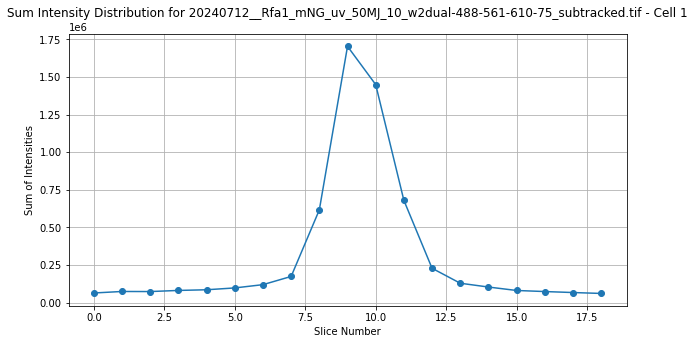

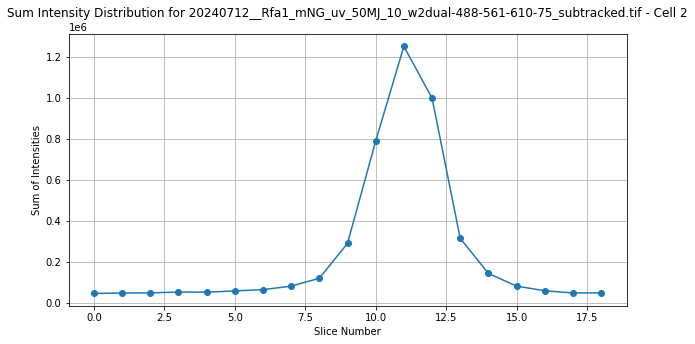

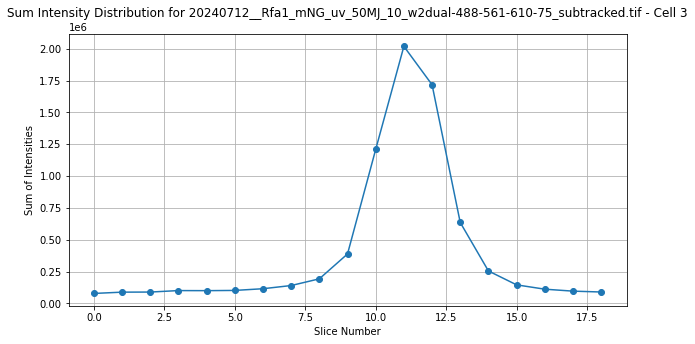

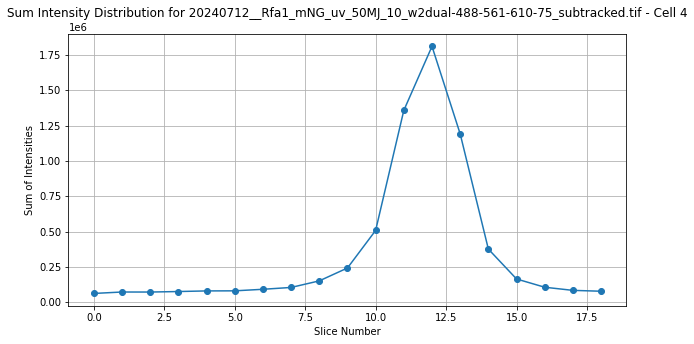

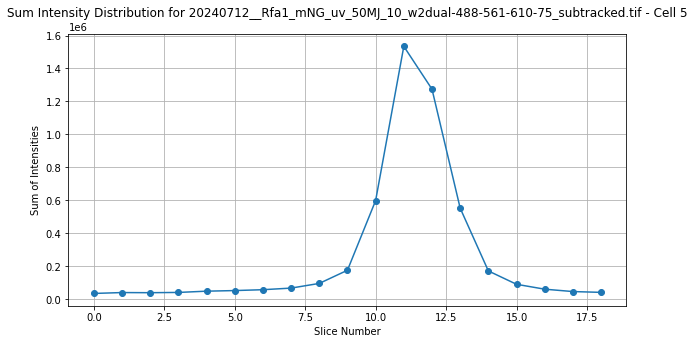

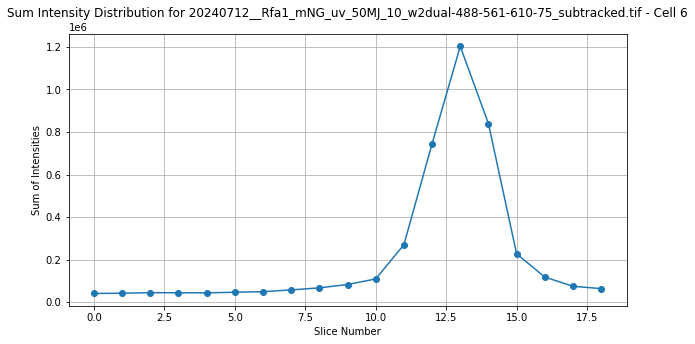

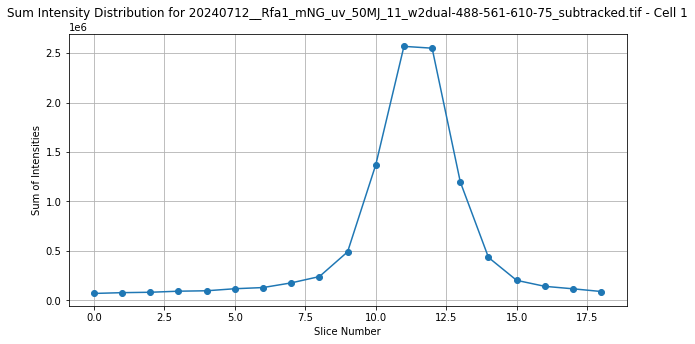

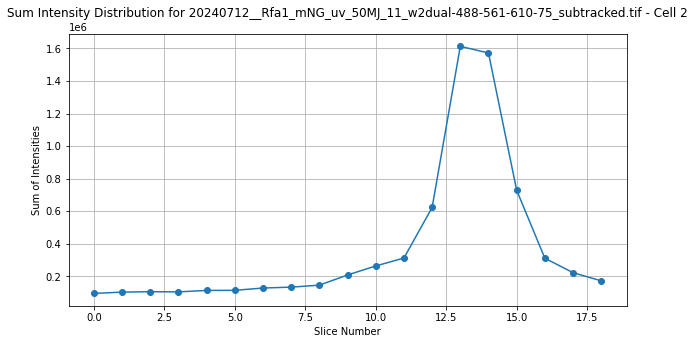

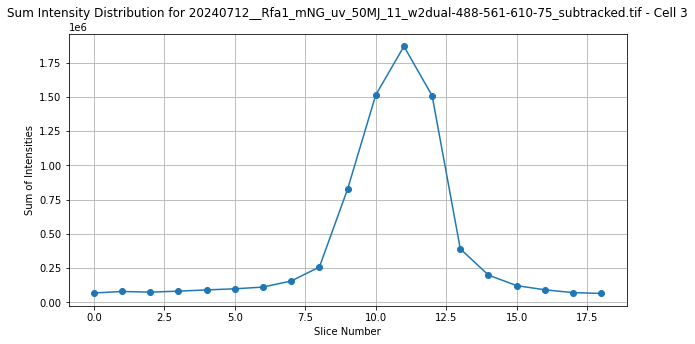

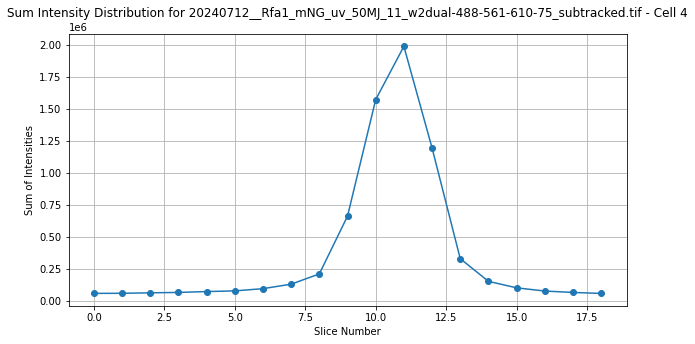

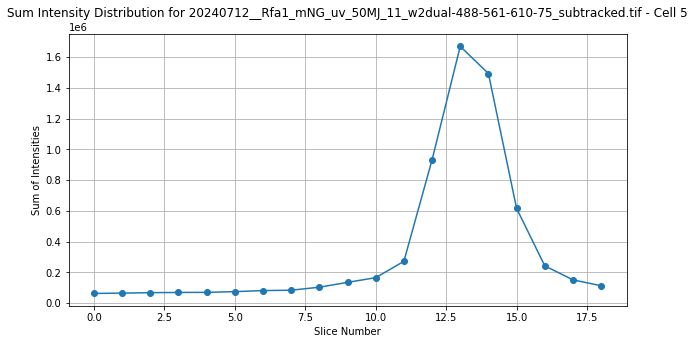

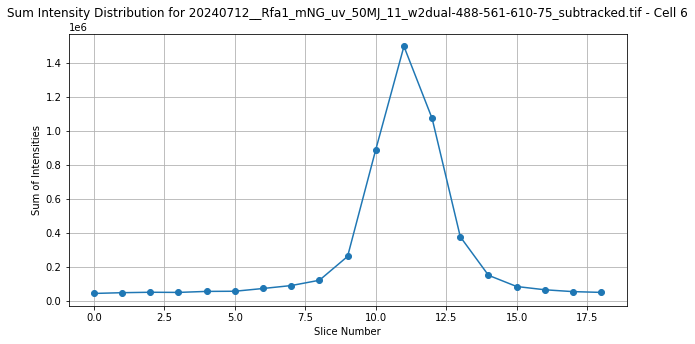

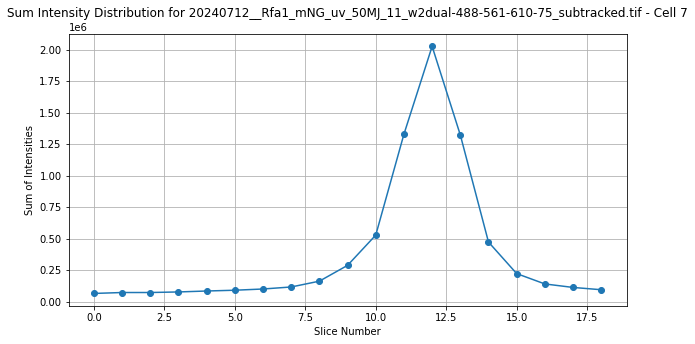

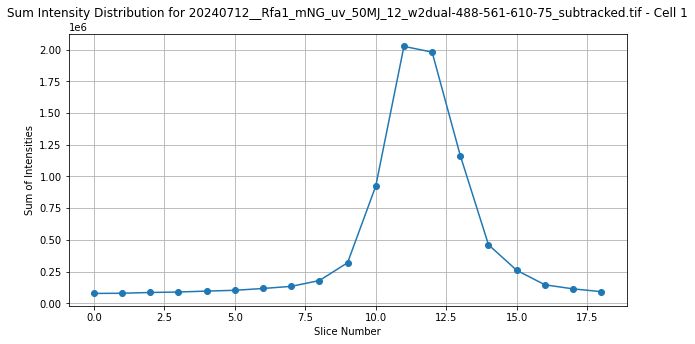

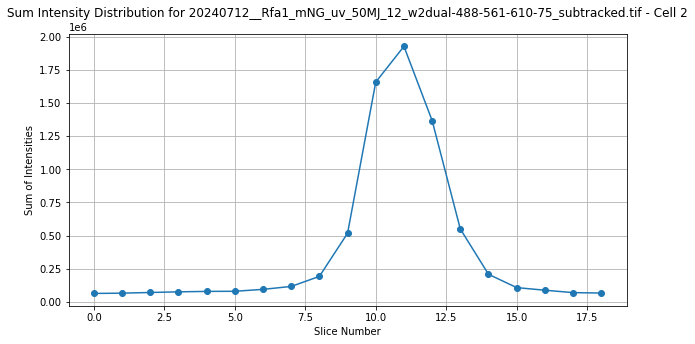

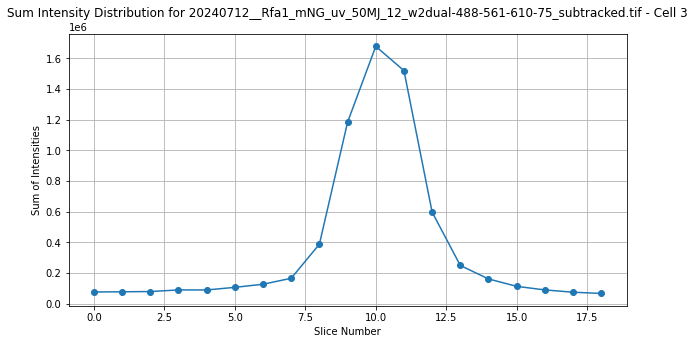

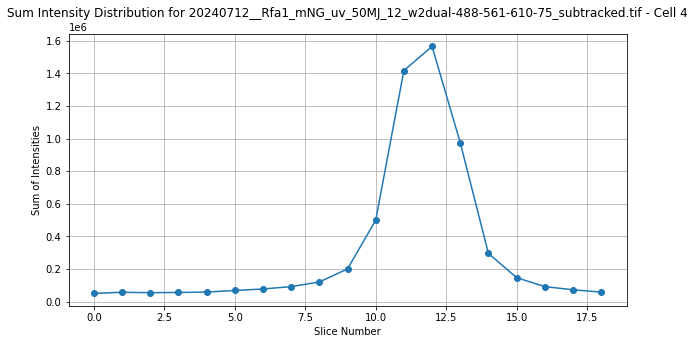

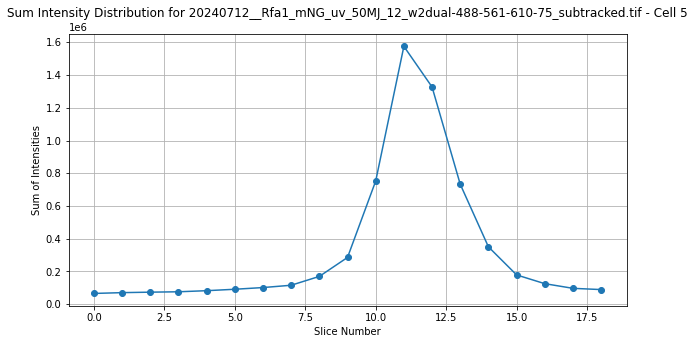

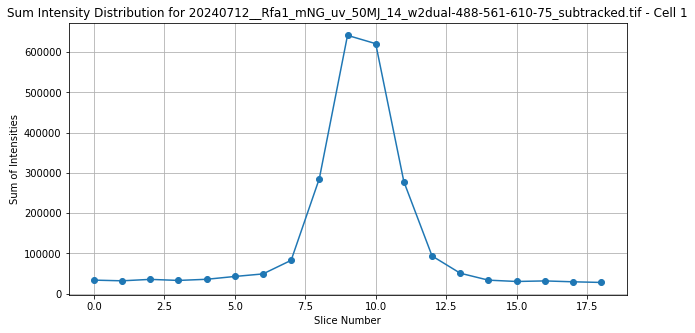

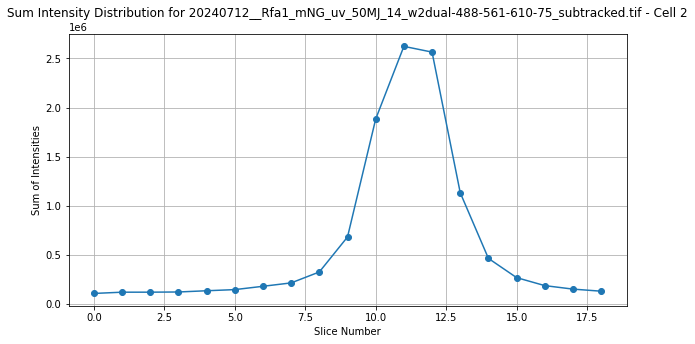

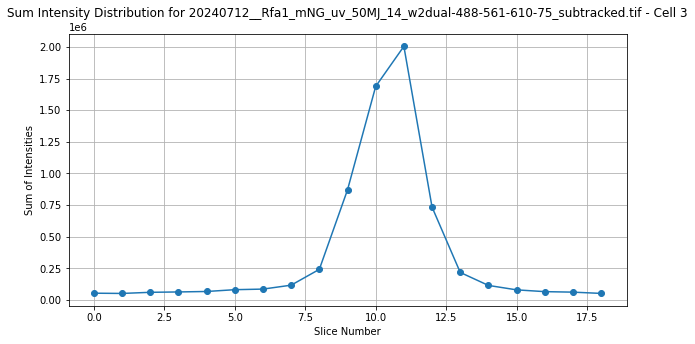

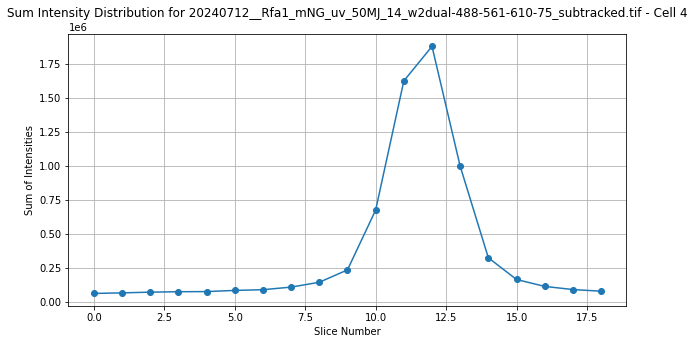

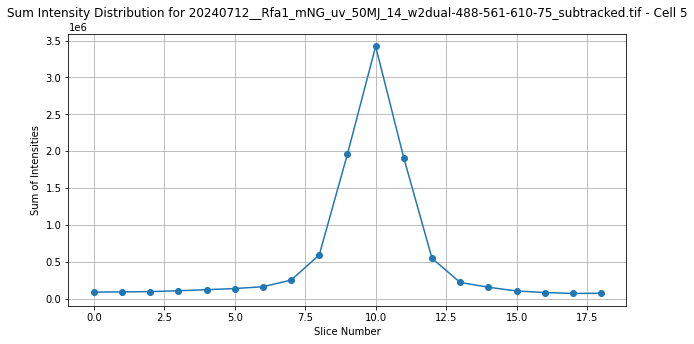

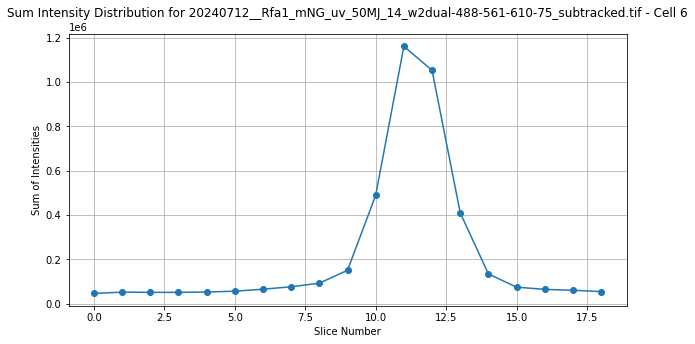

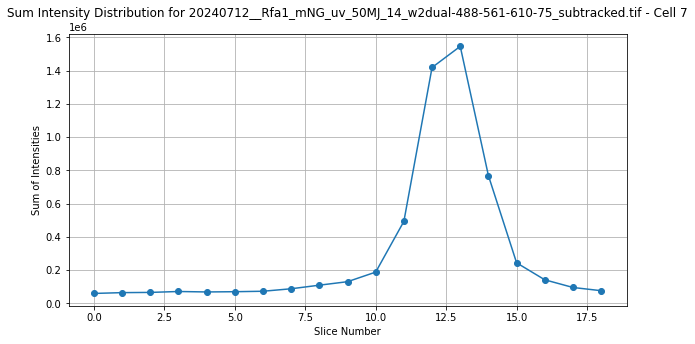

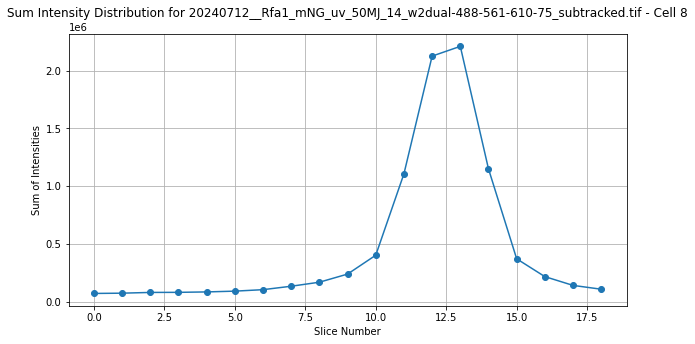

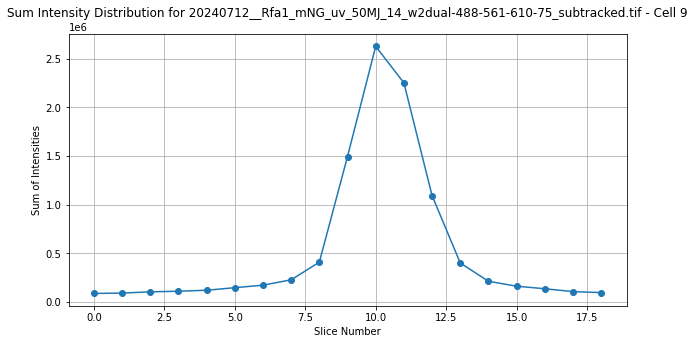

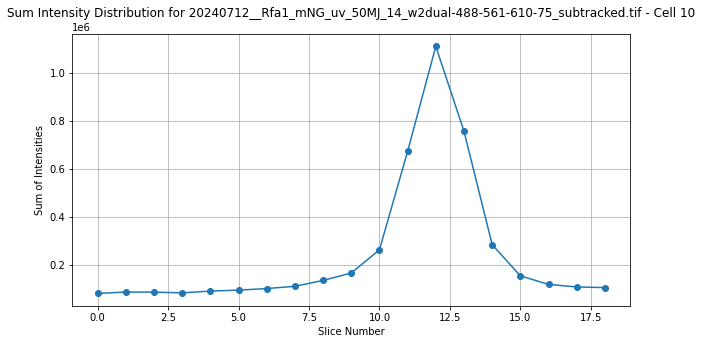

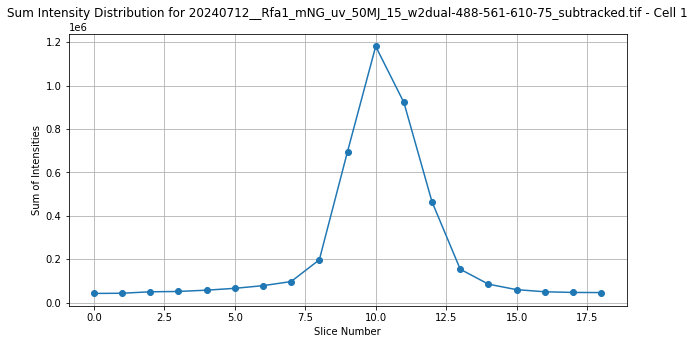

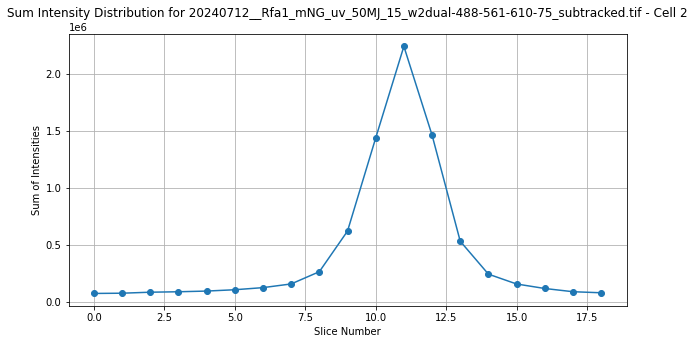

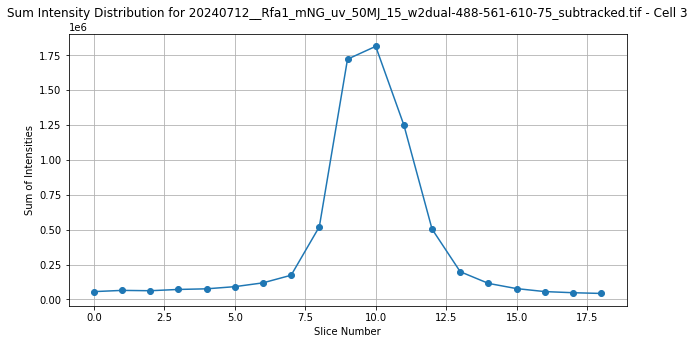

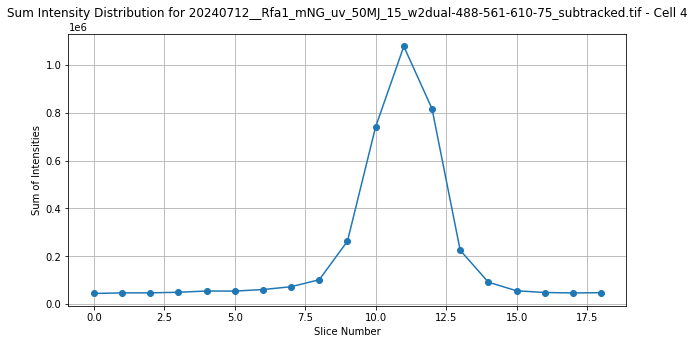

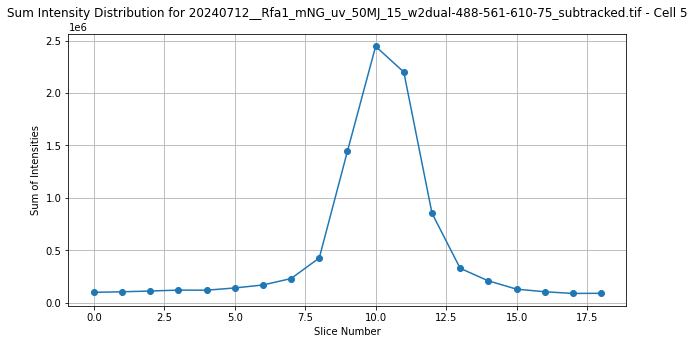

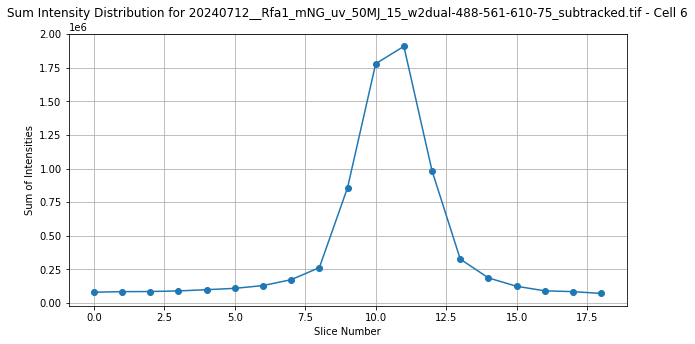

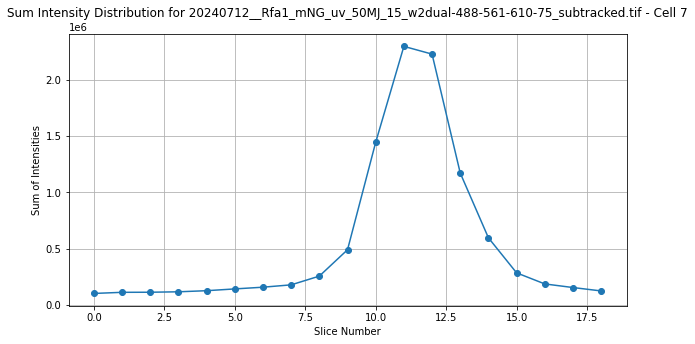

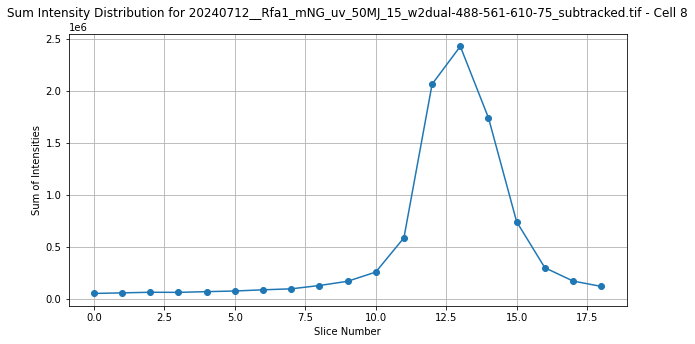

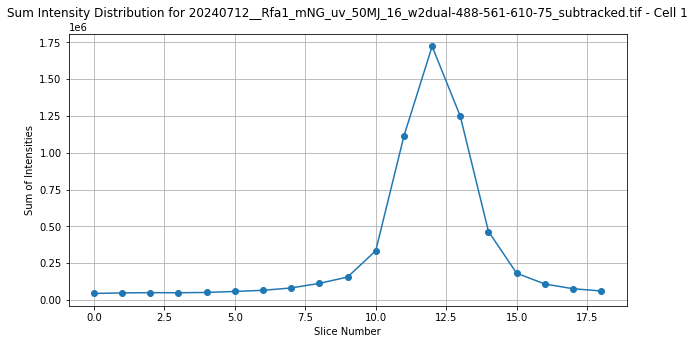

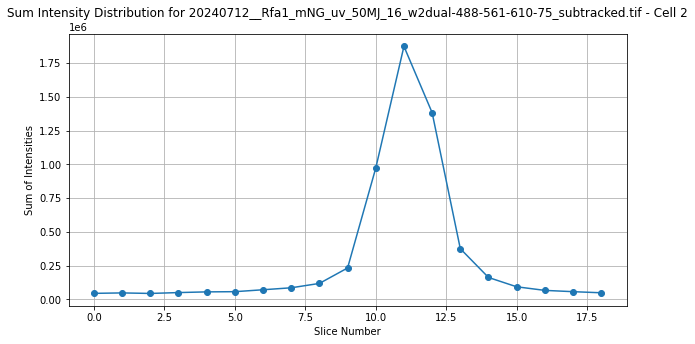

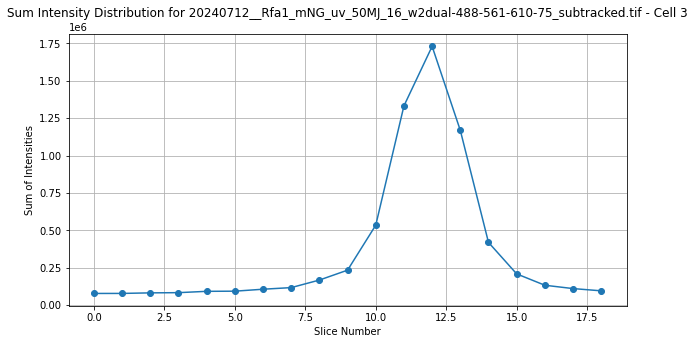

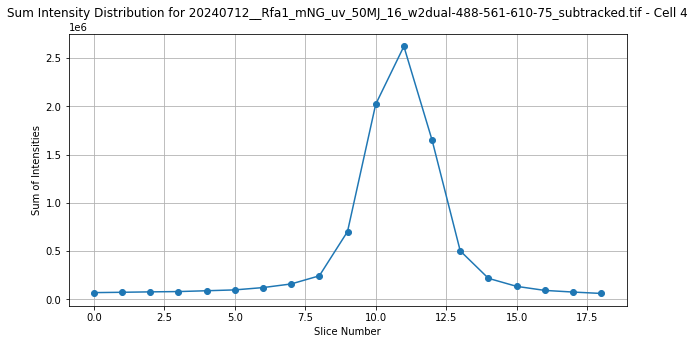

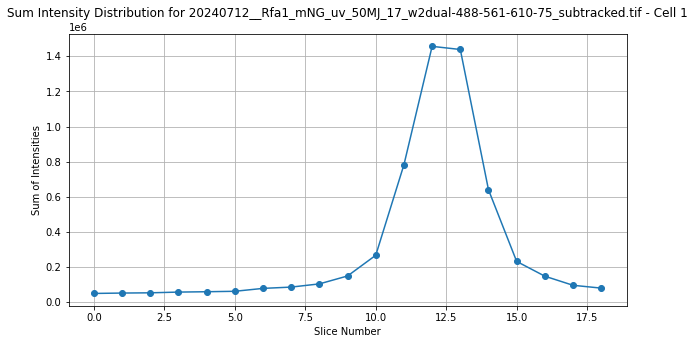

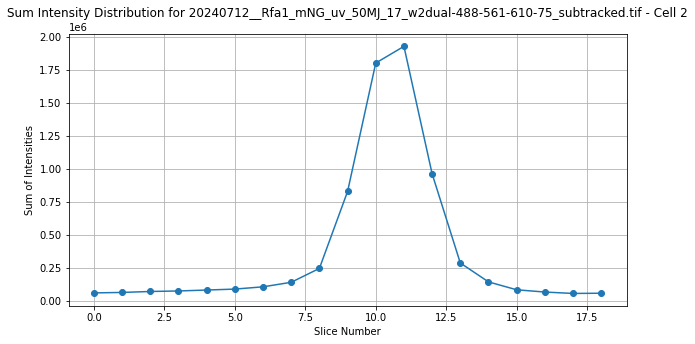

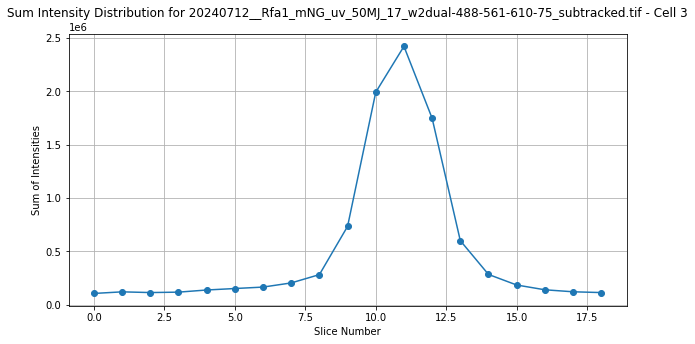

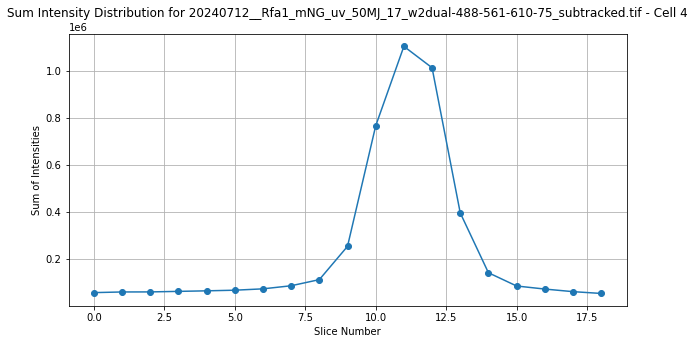

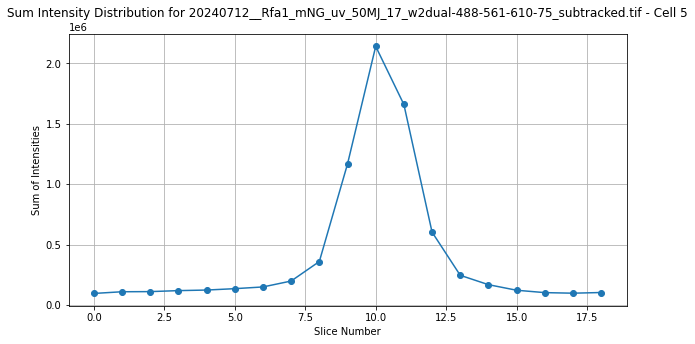

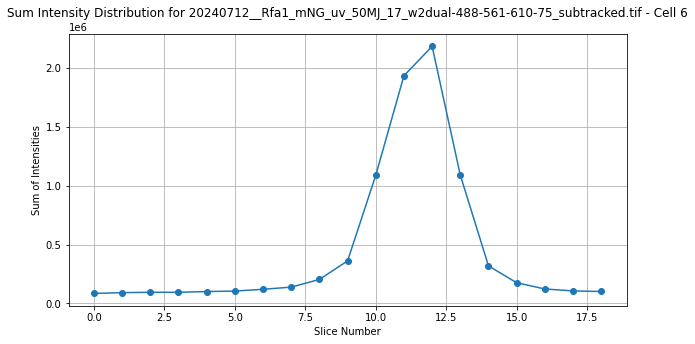

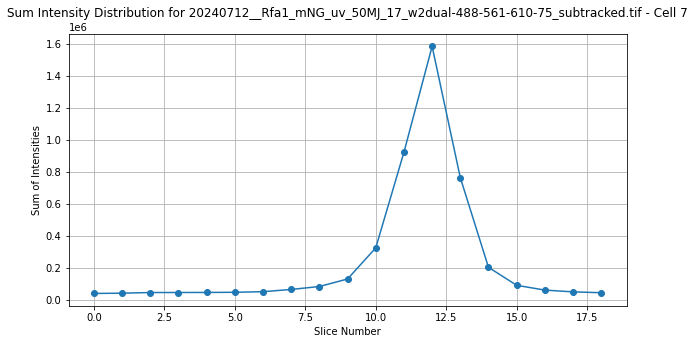

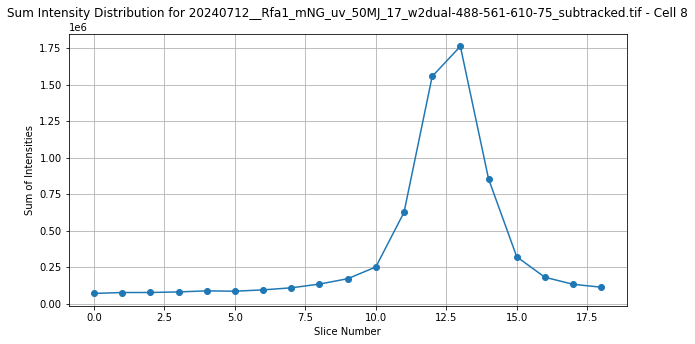

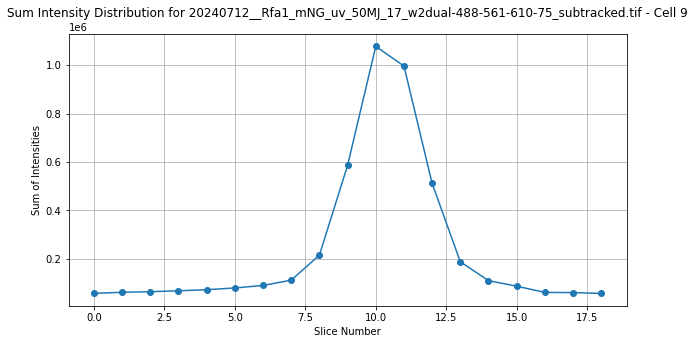

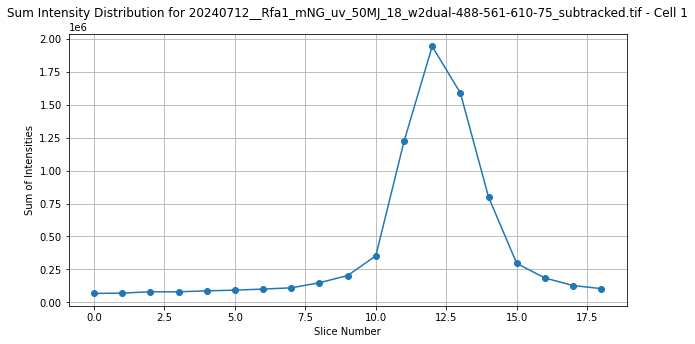

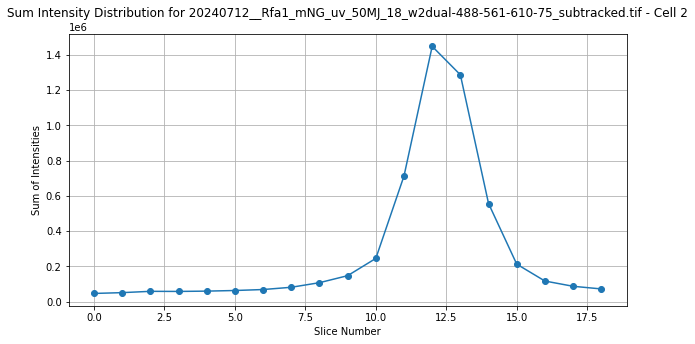

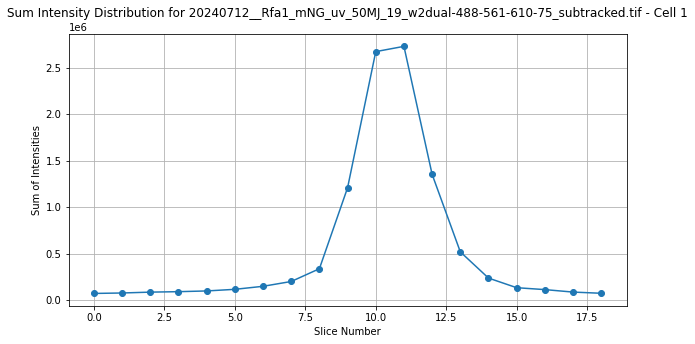

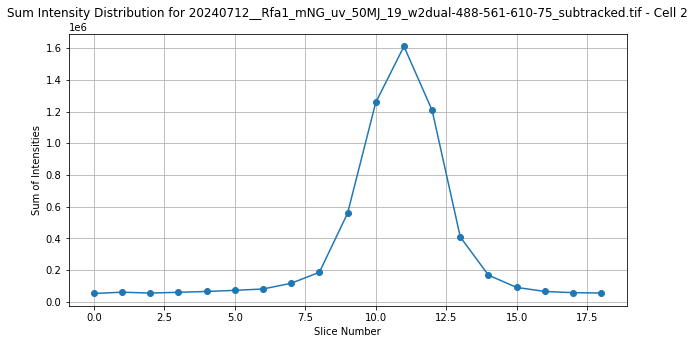

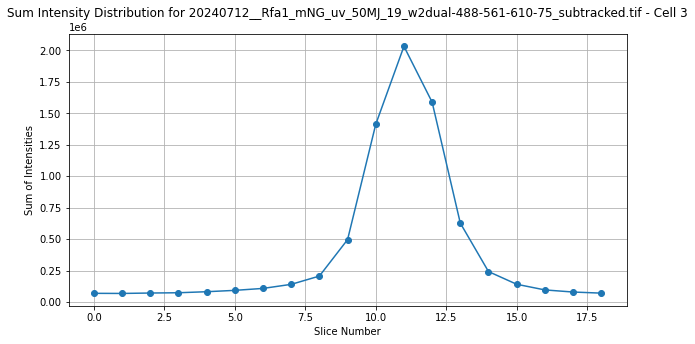

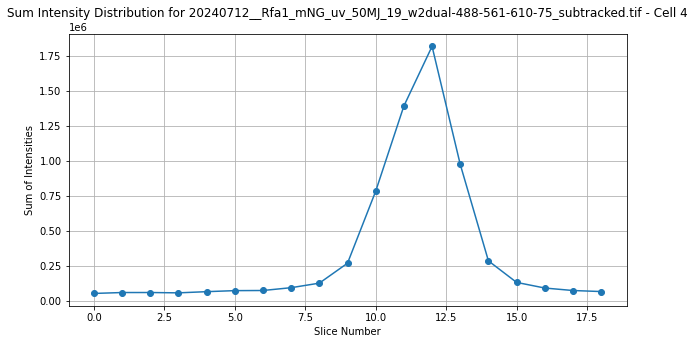

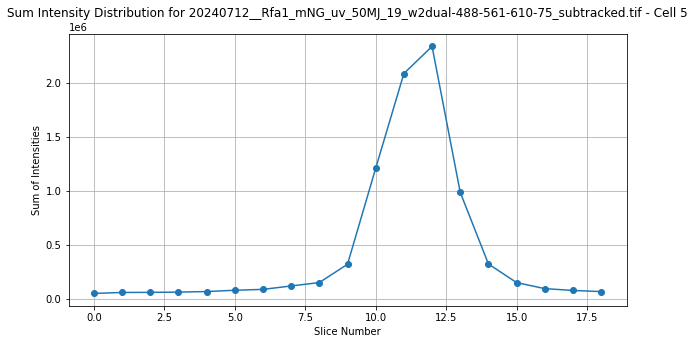

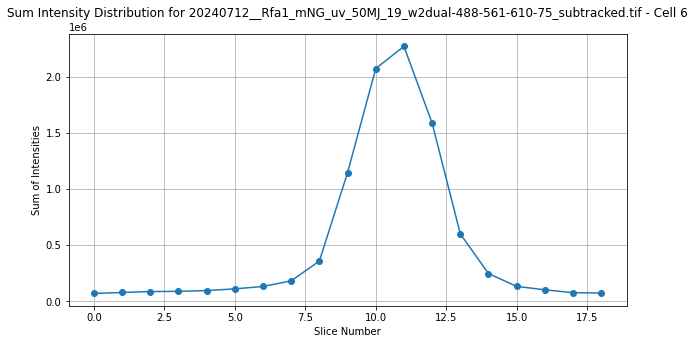

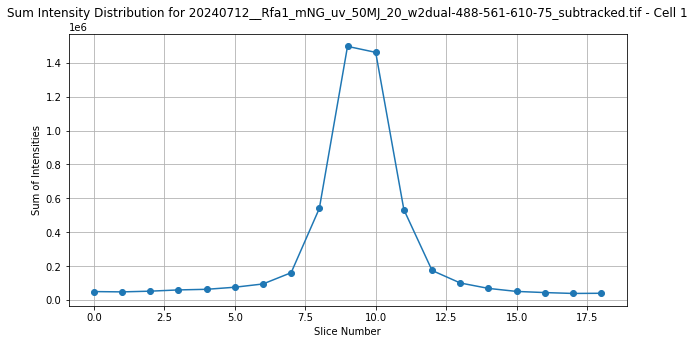

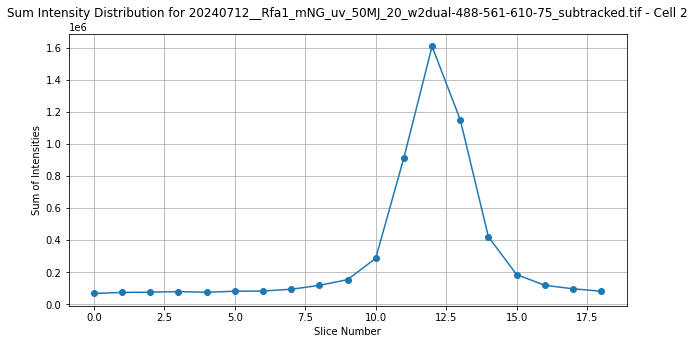

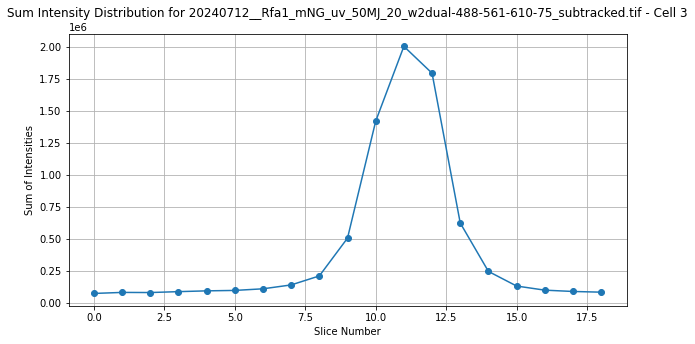

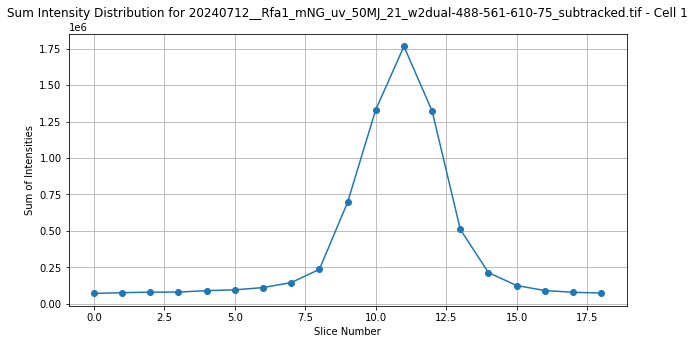

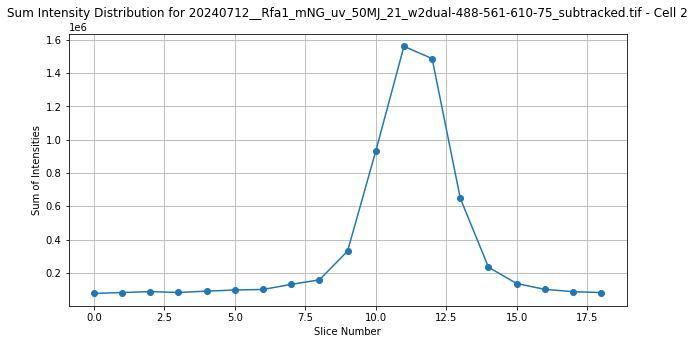

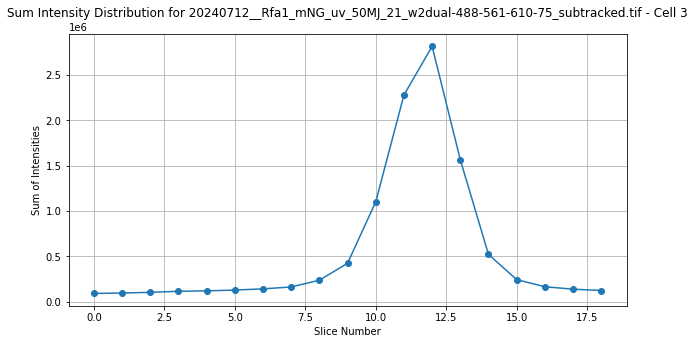

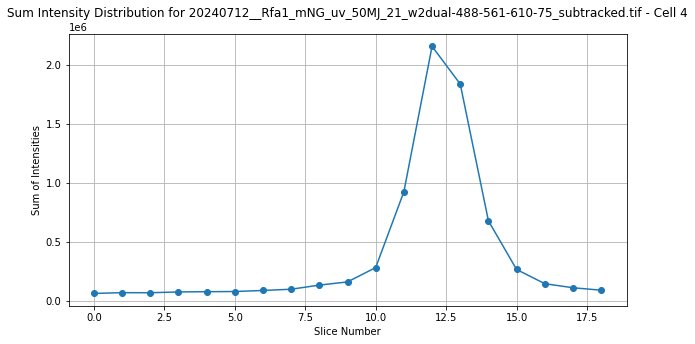

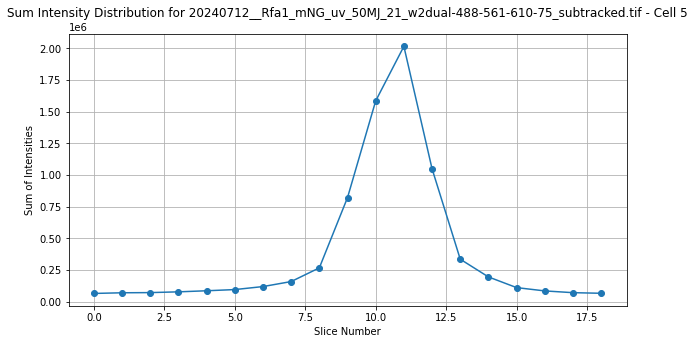

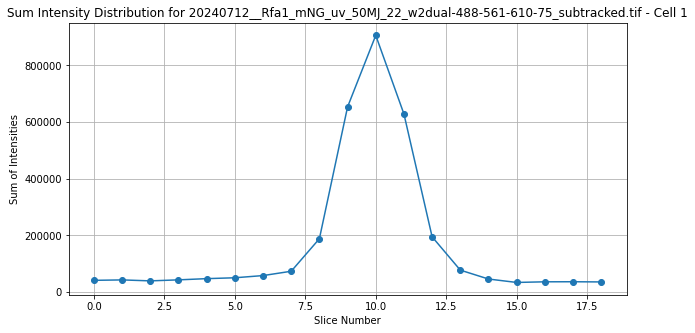

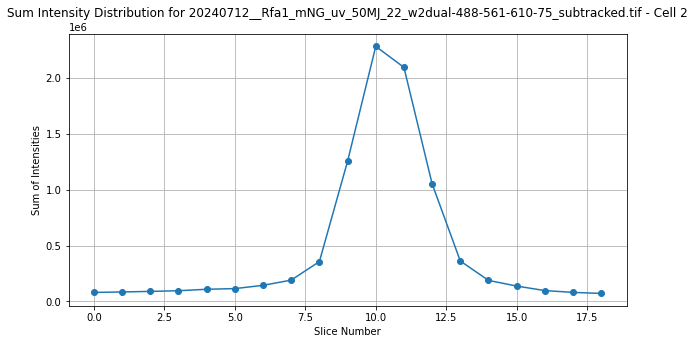

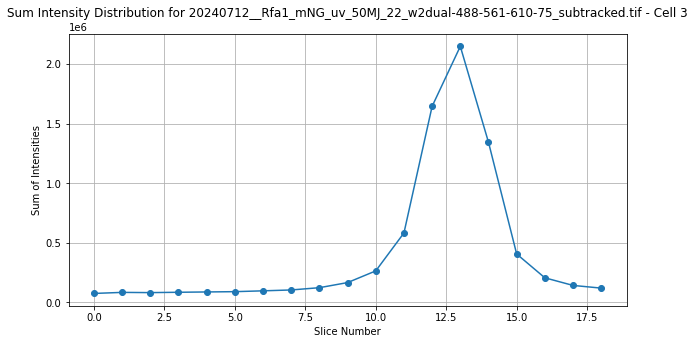

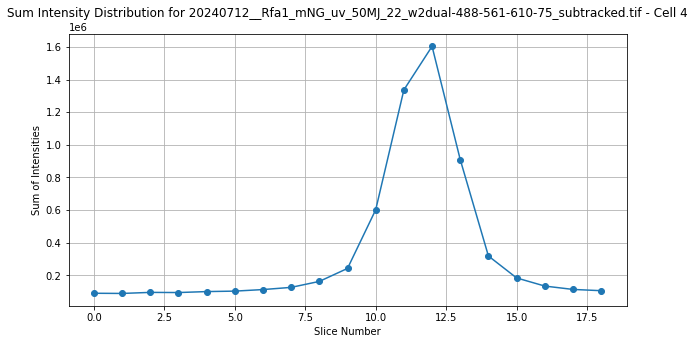

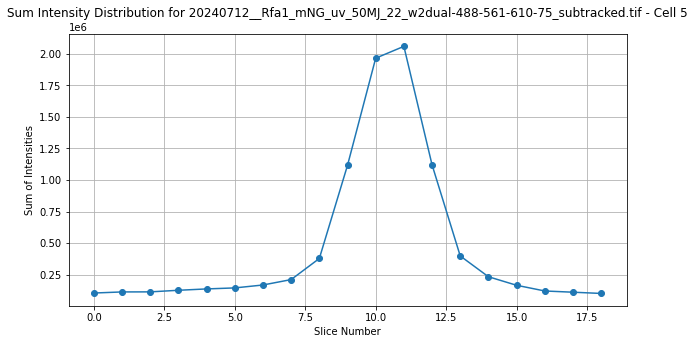

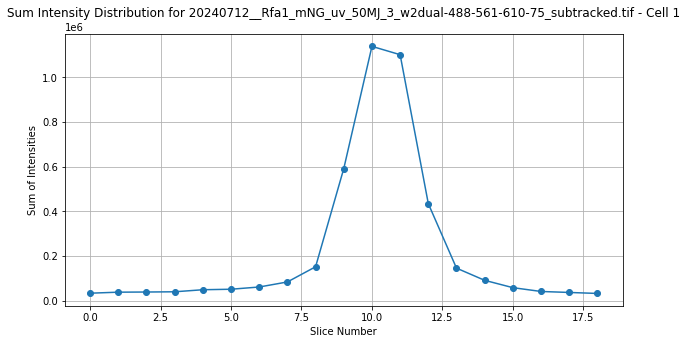

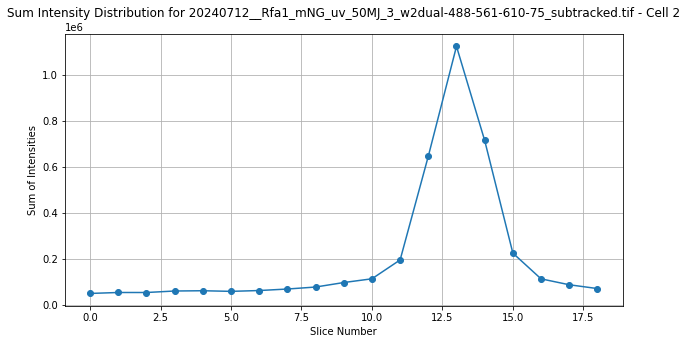

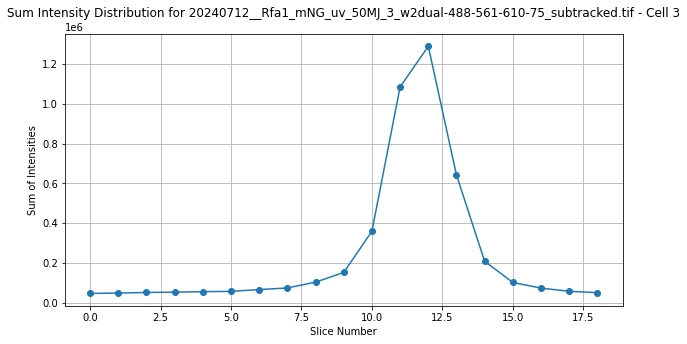

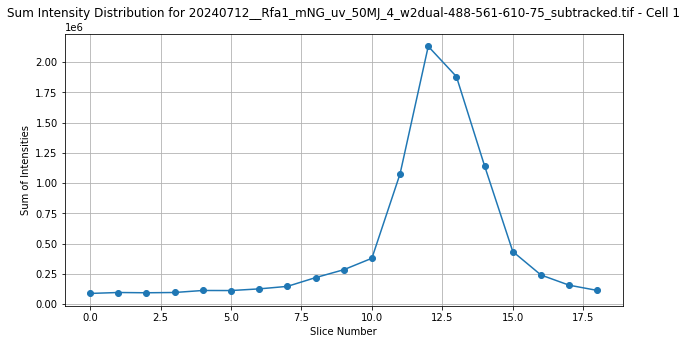

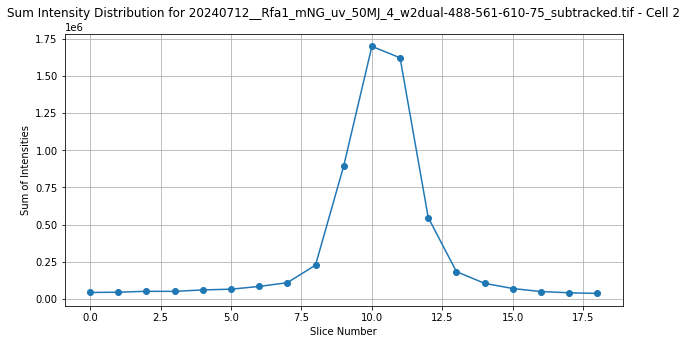

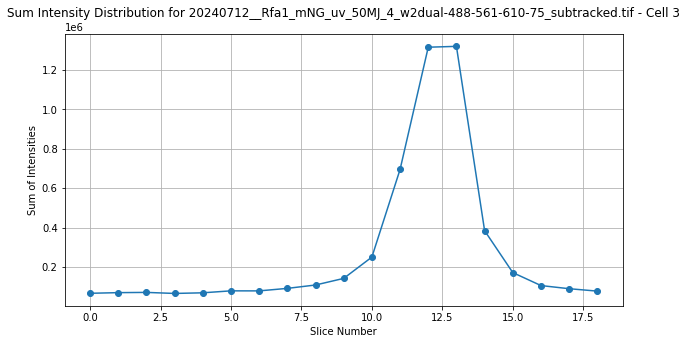

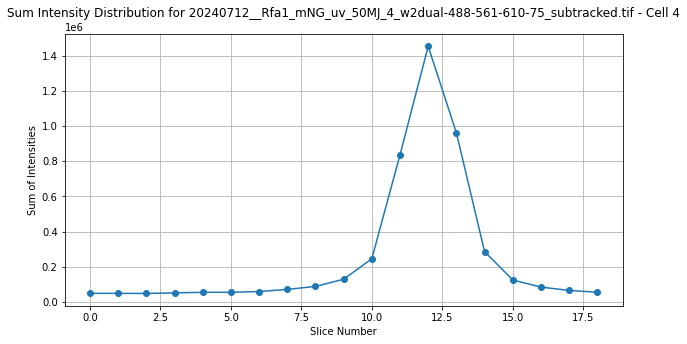

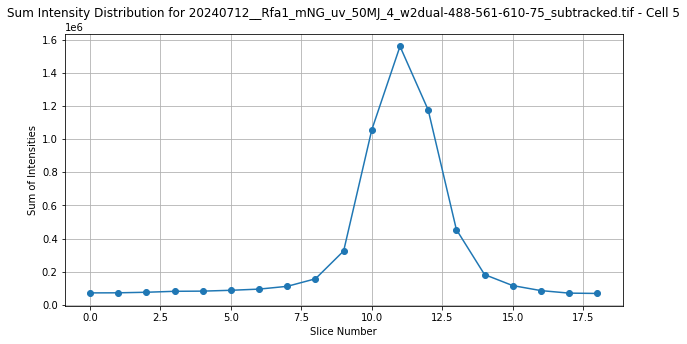

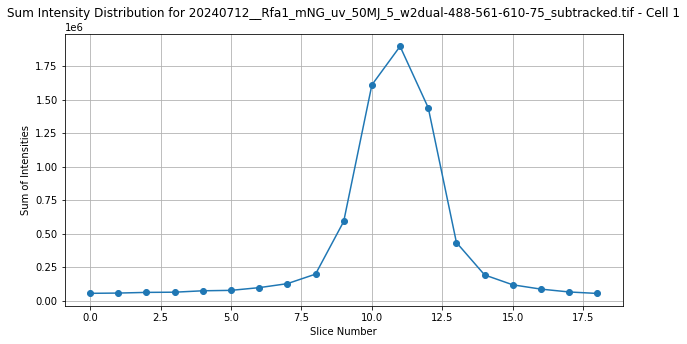

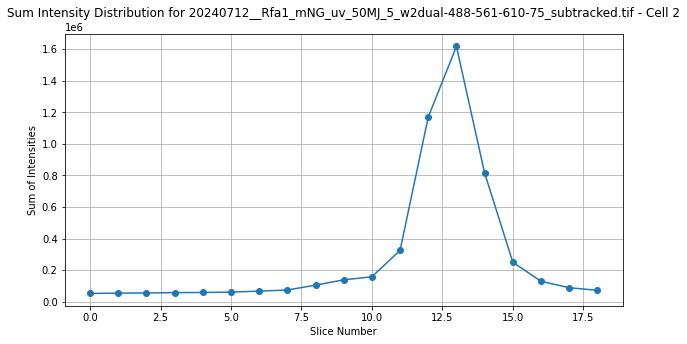

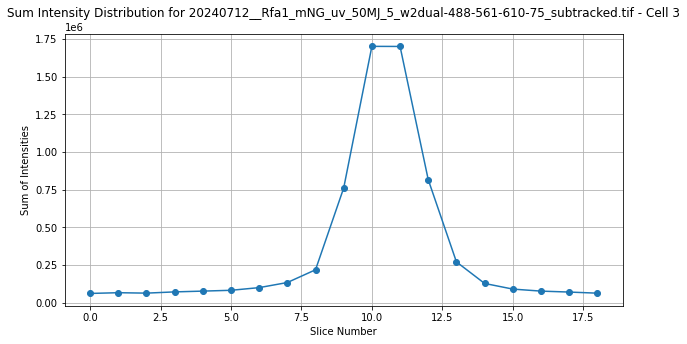

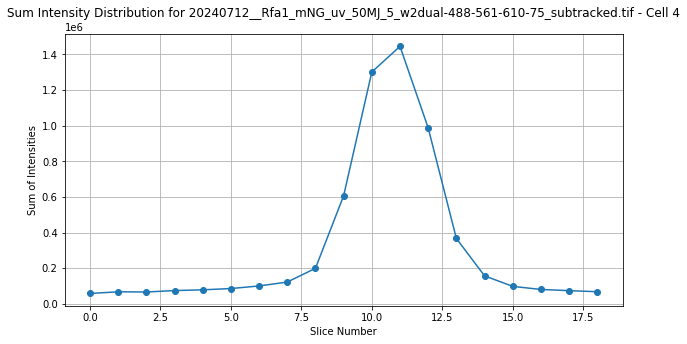

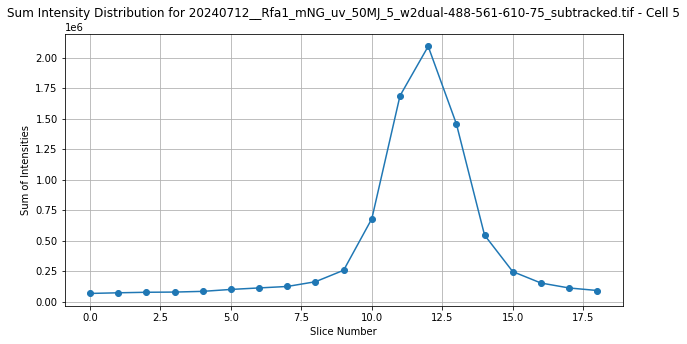

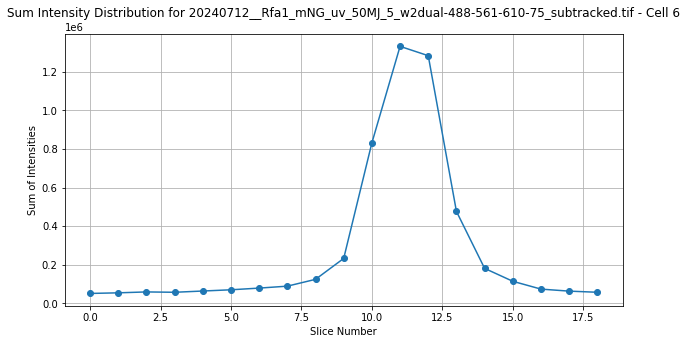

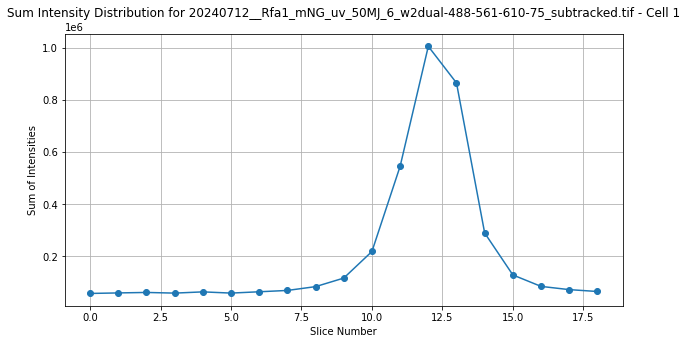

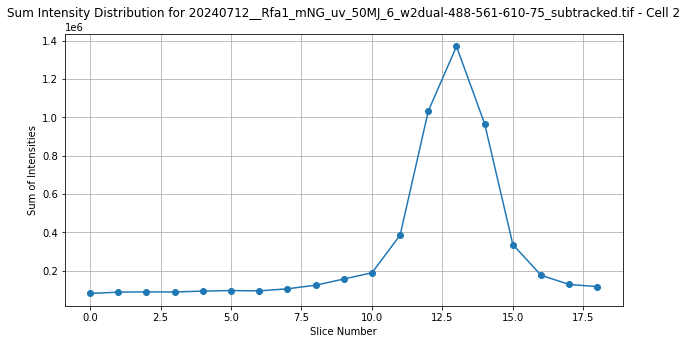

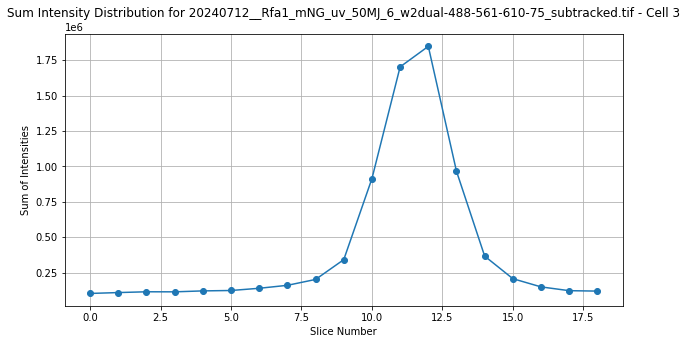

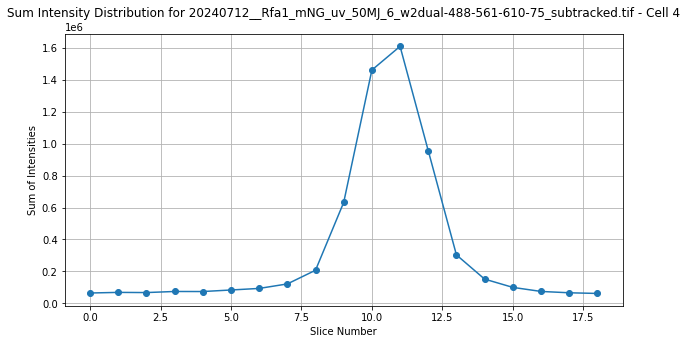

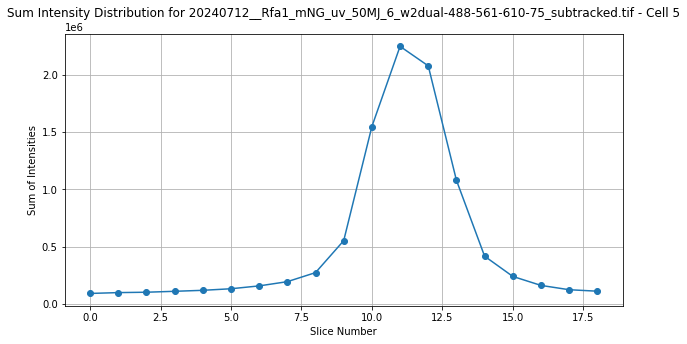

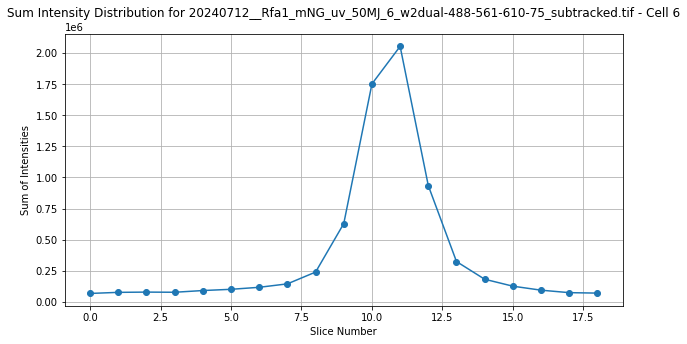

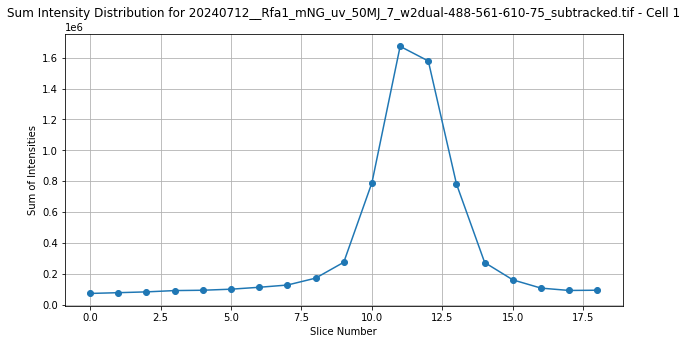

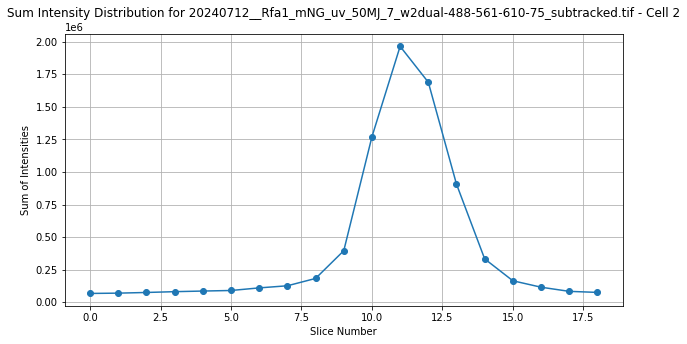

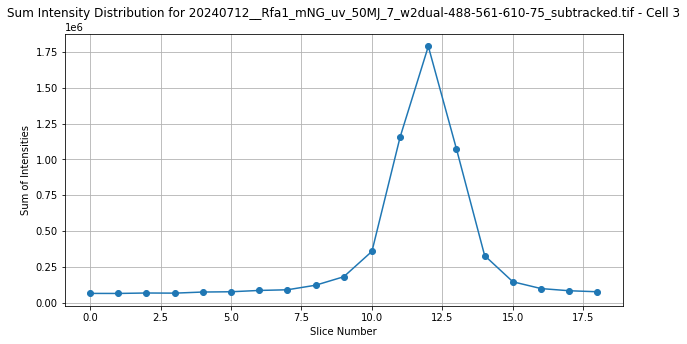

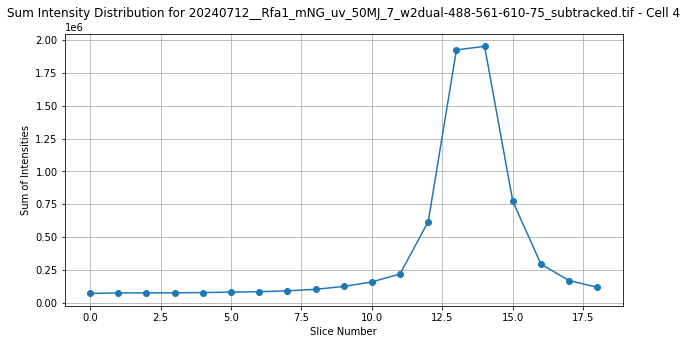

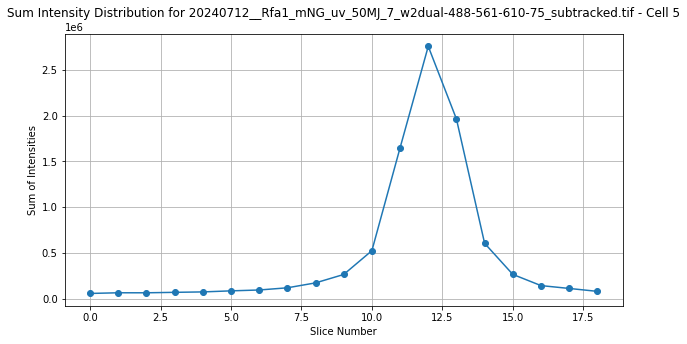

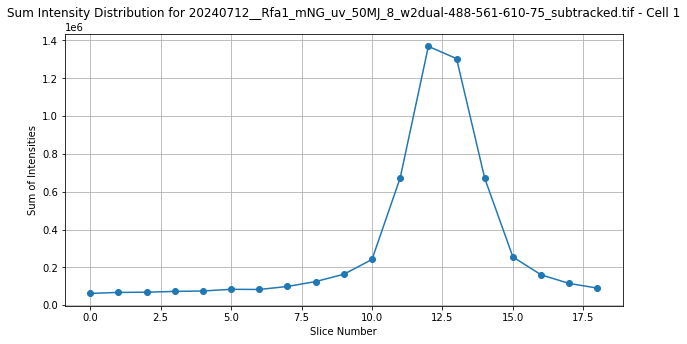

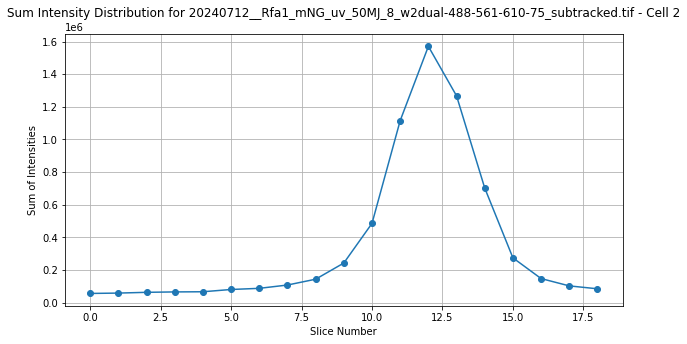

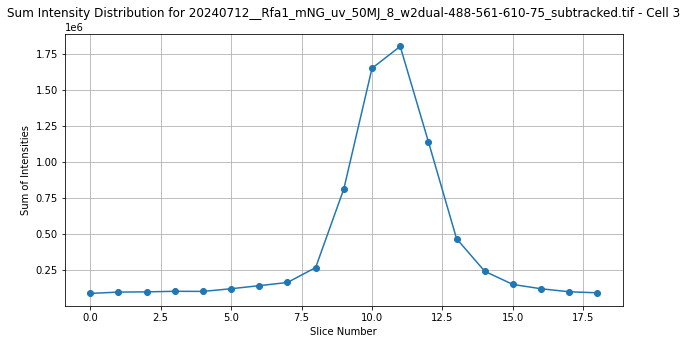

In [16]:
analyze_intensity_distribution(segmented_stacks_df)

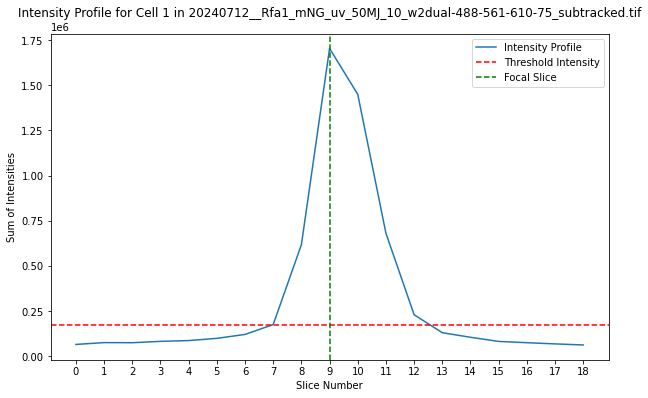

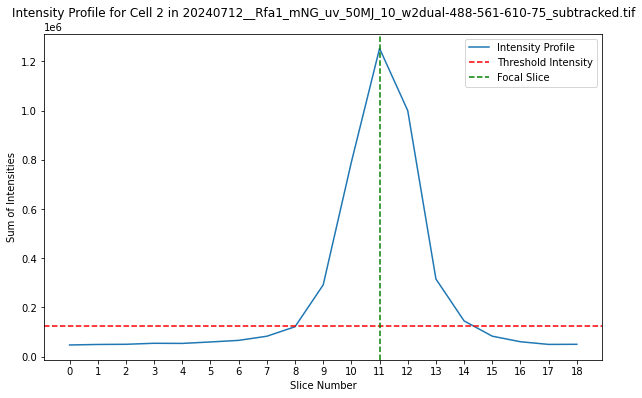

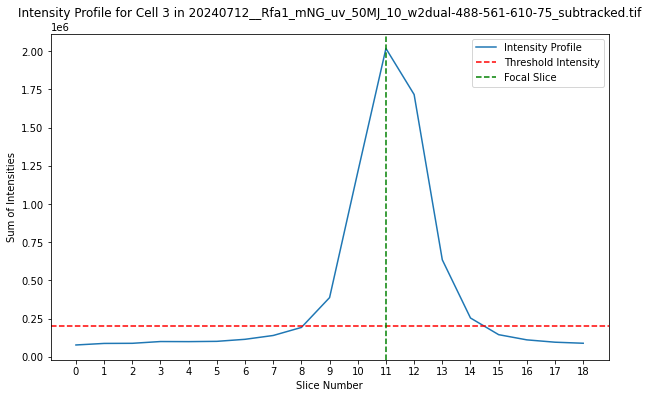

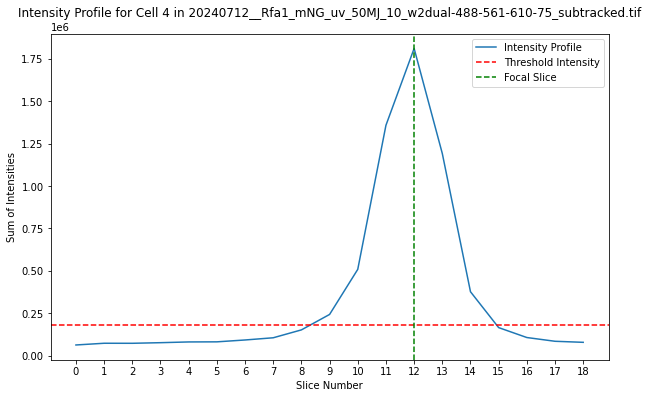

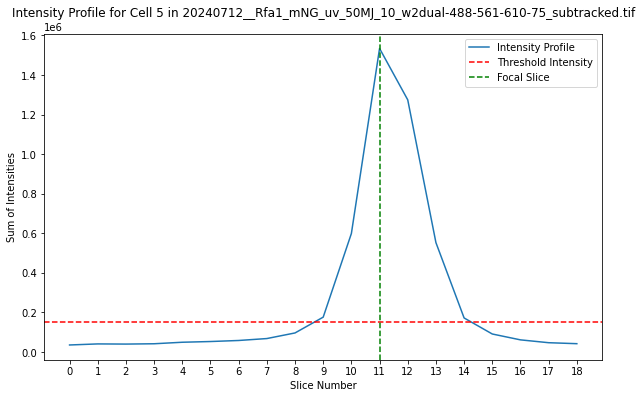

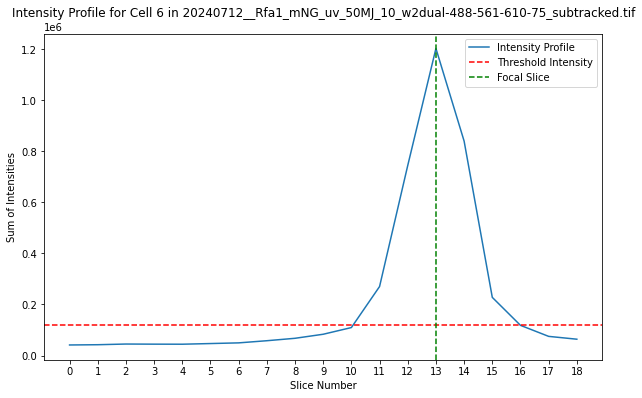

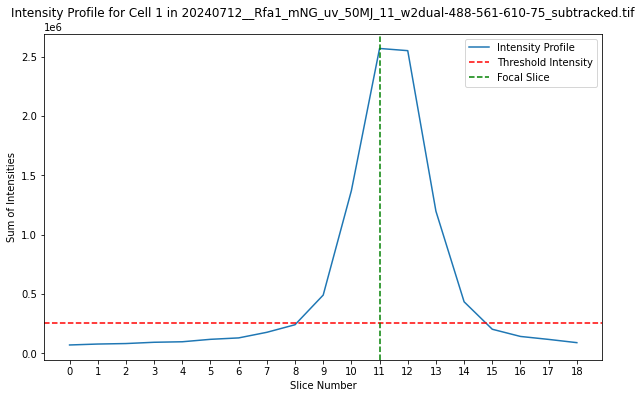

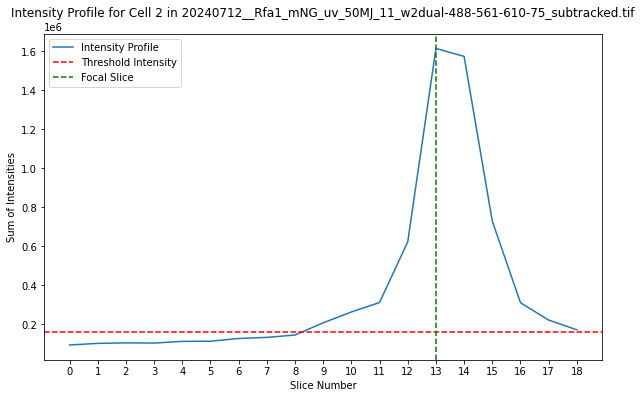

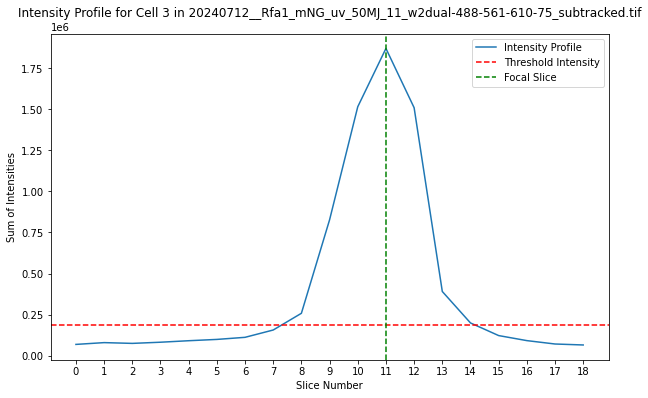

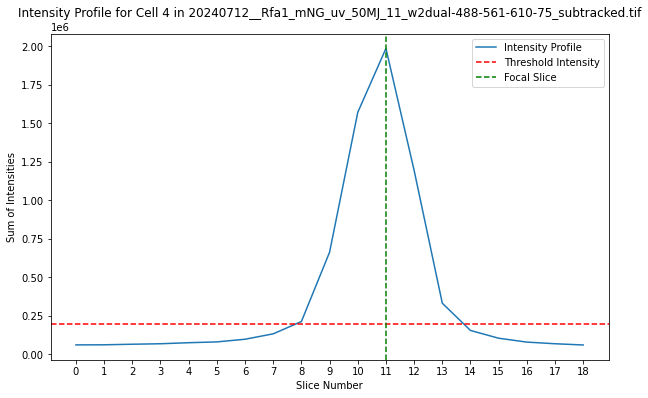

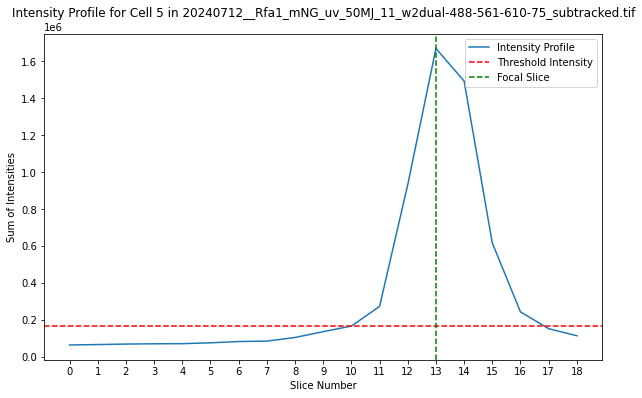

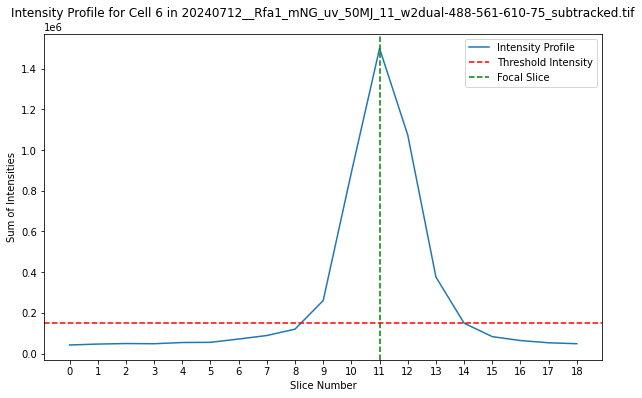

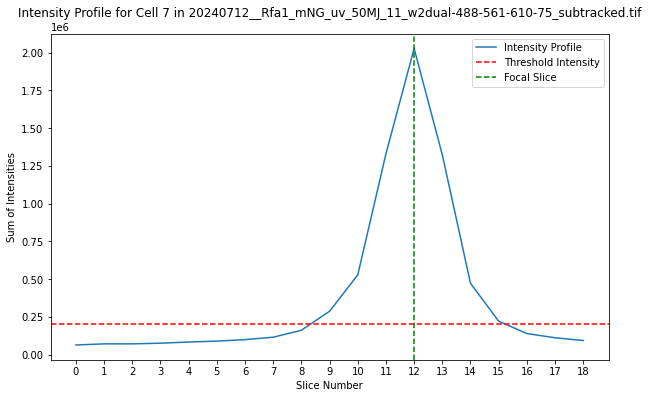

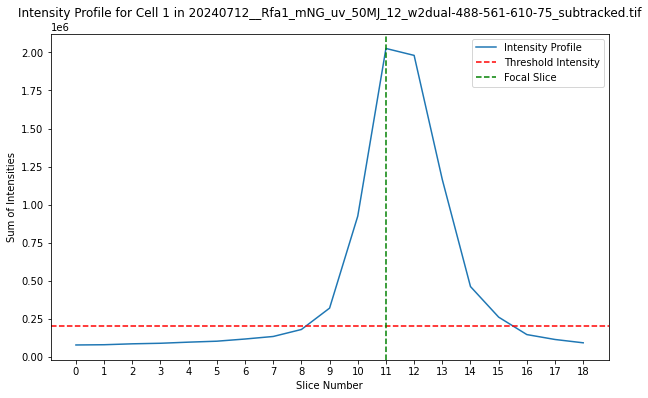

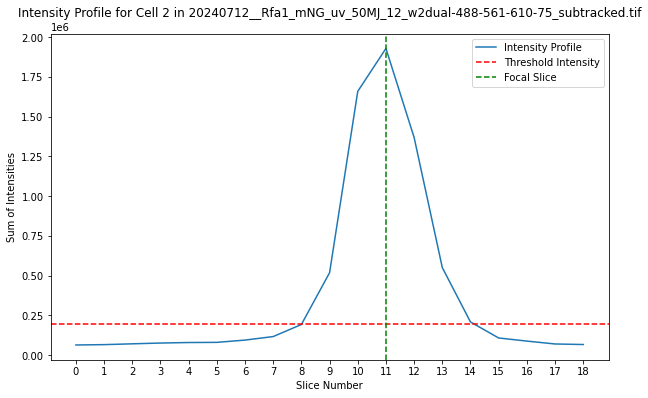

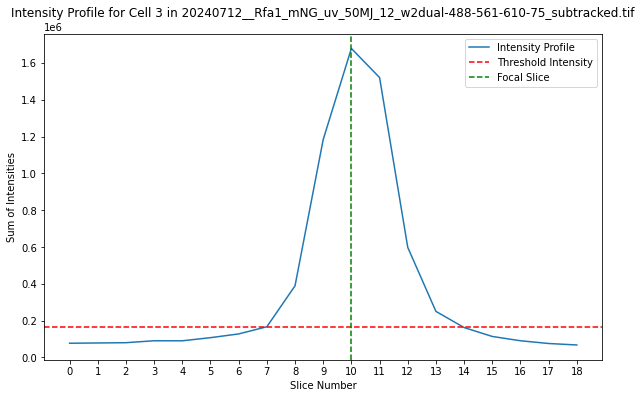

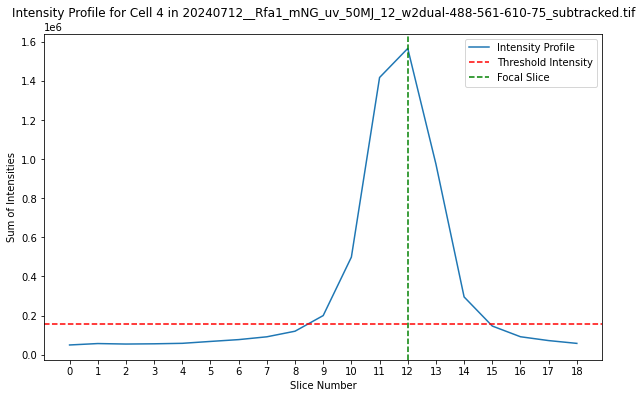

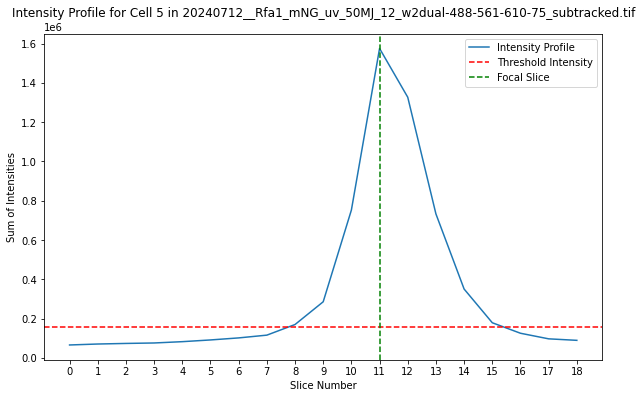

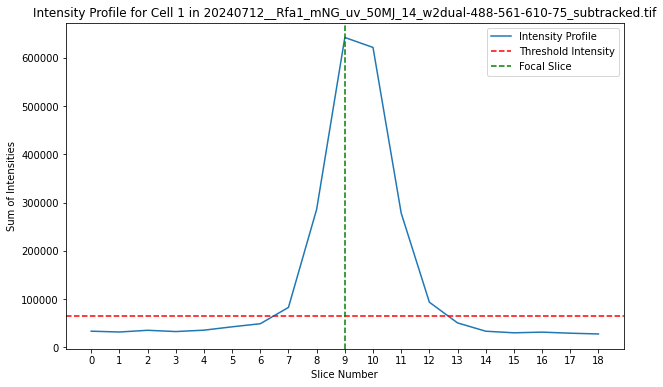

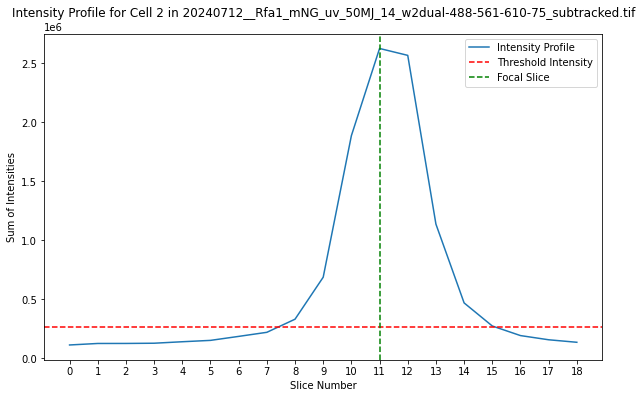

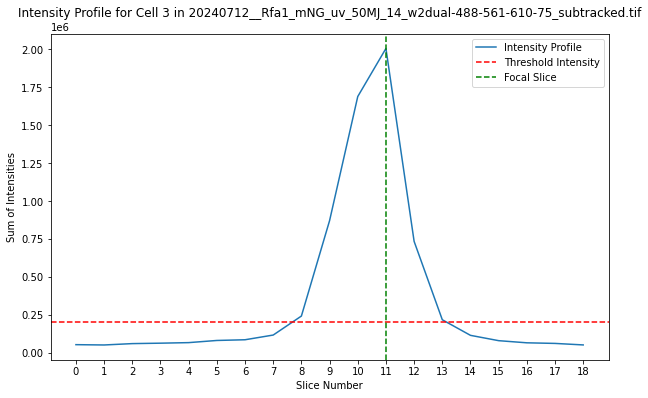

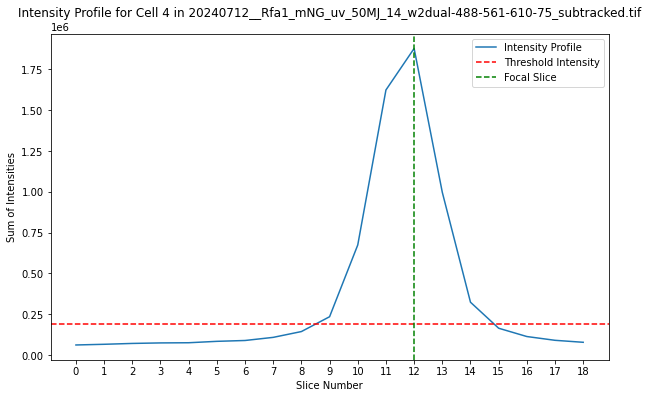

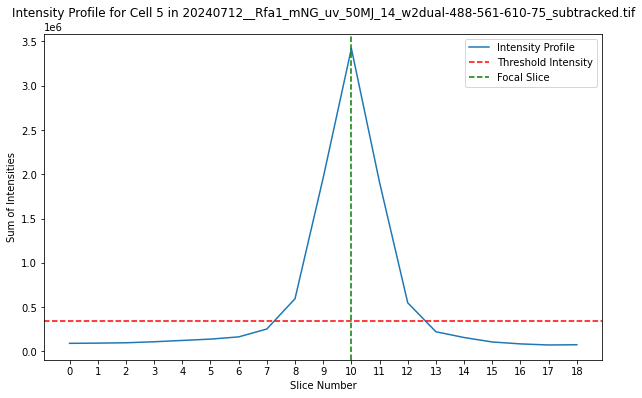

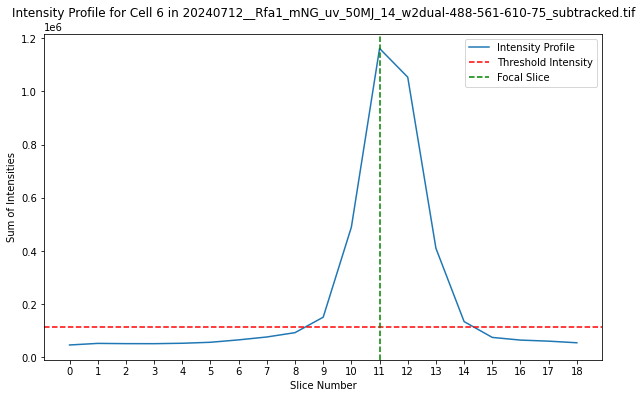

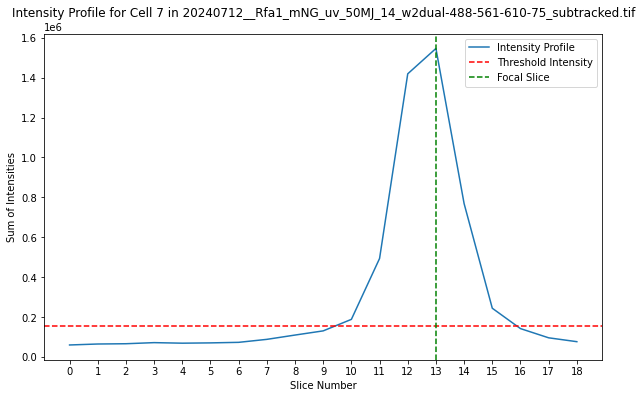

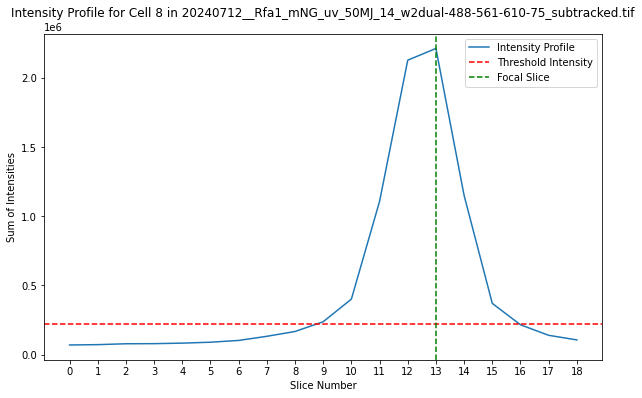

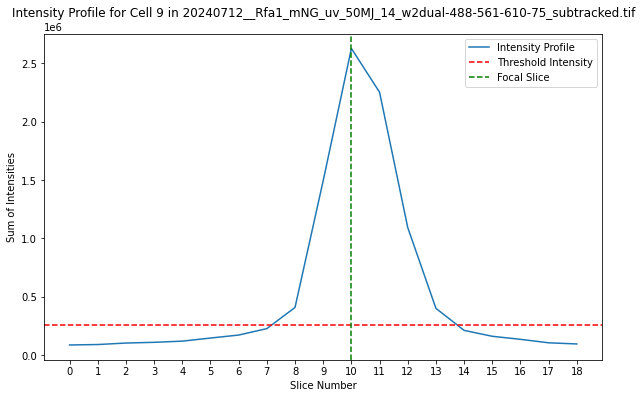

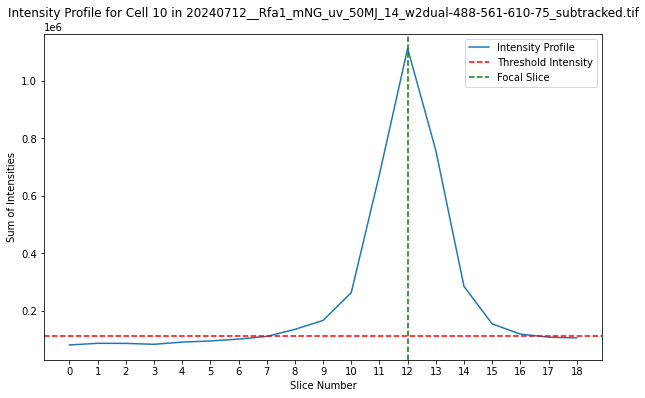

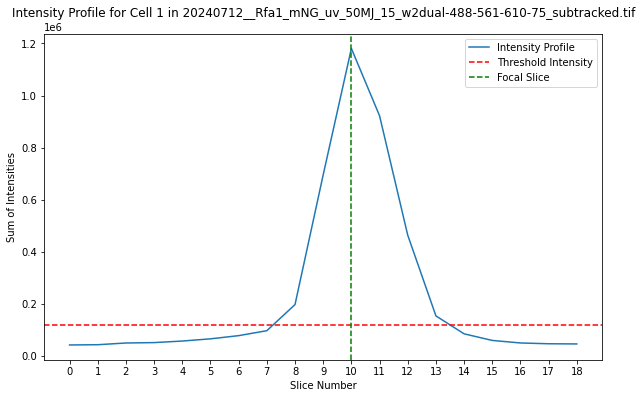

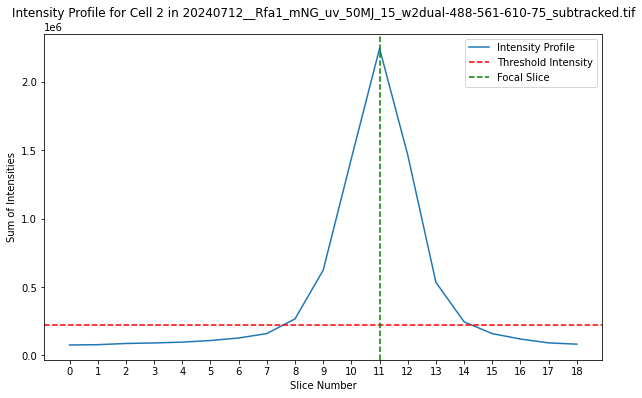

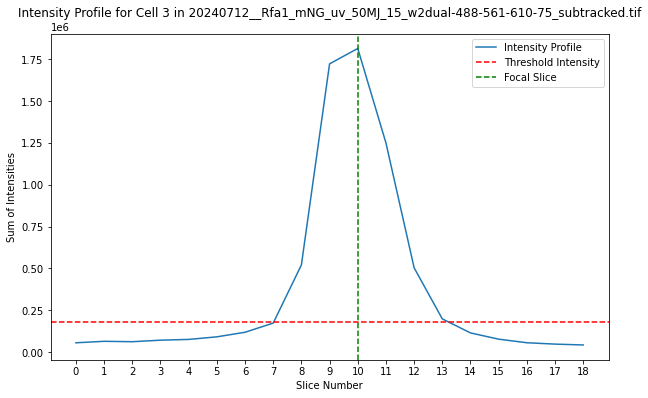

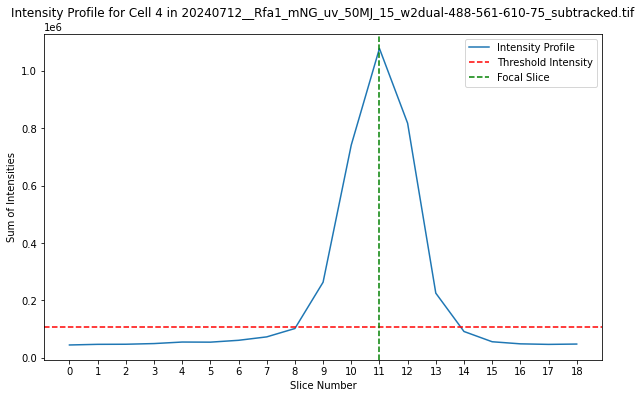

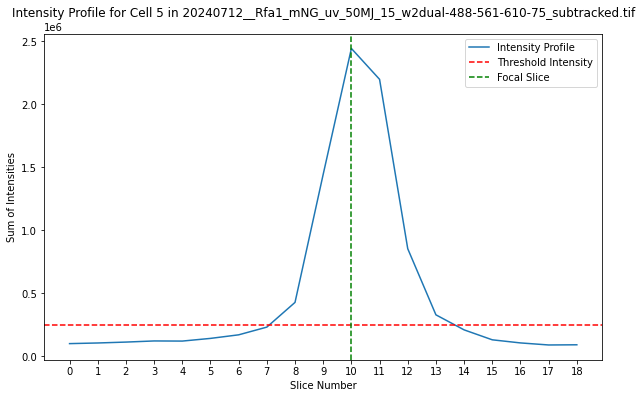

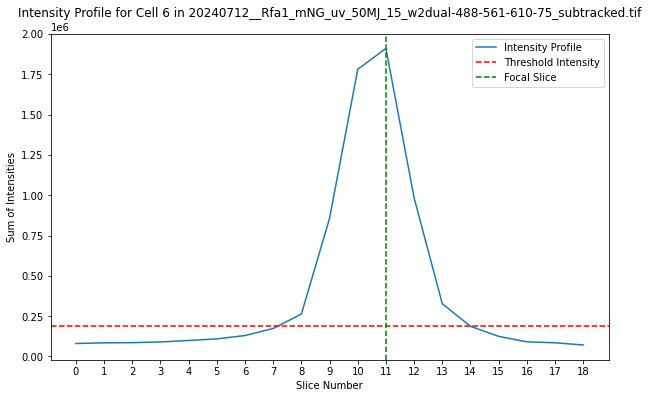

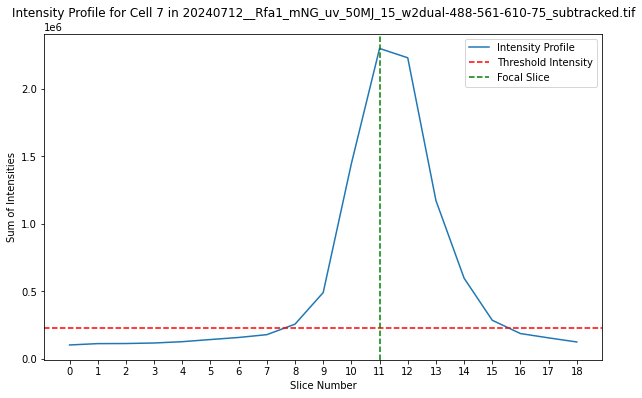

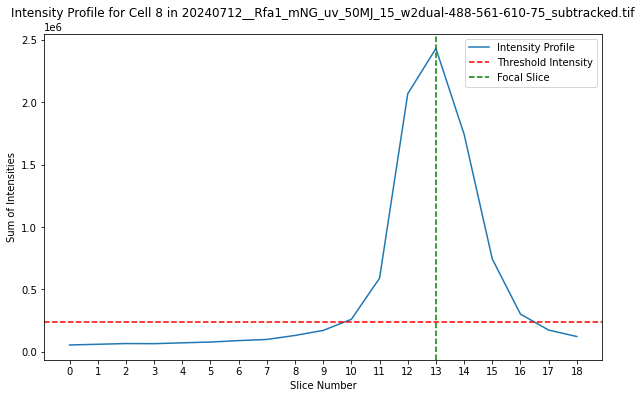

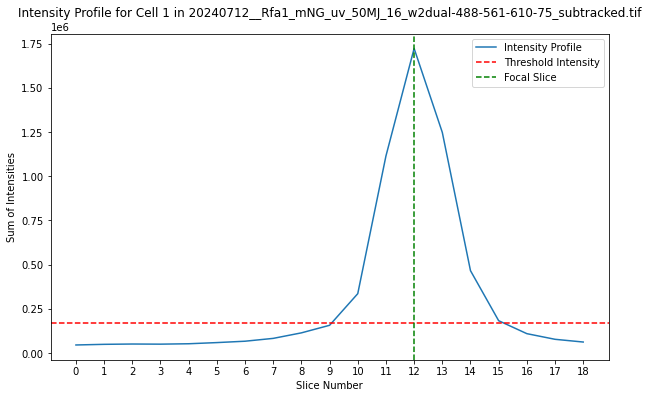

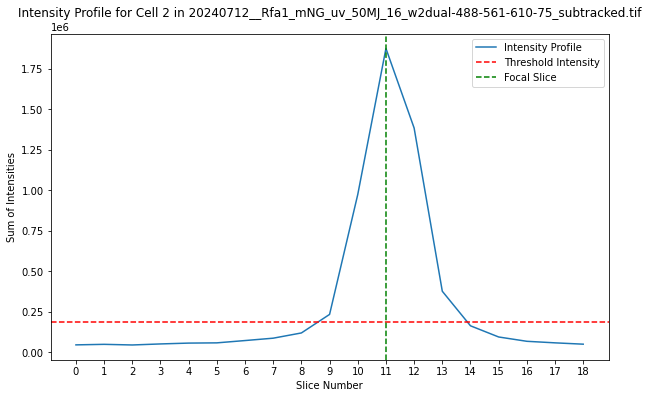

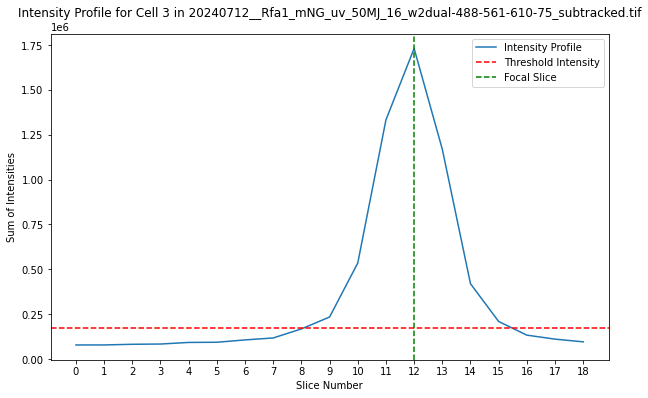

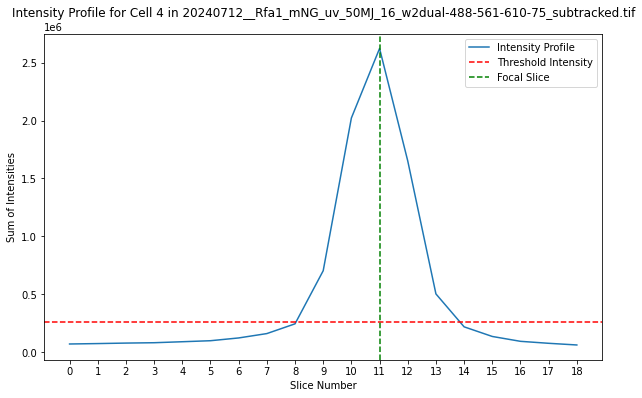

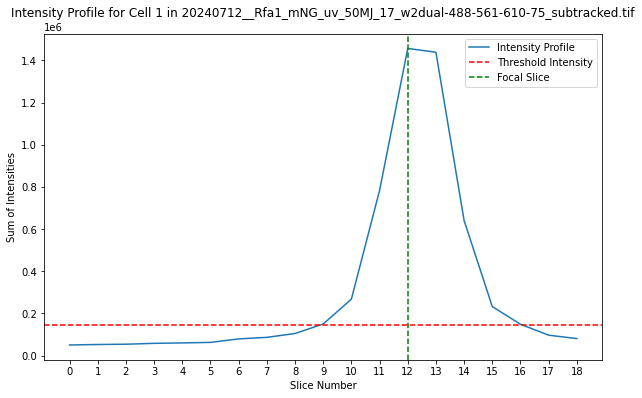

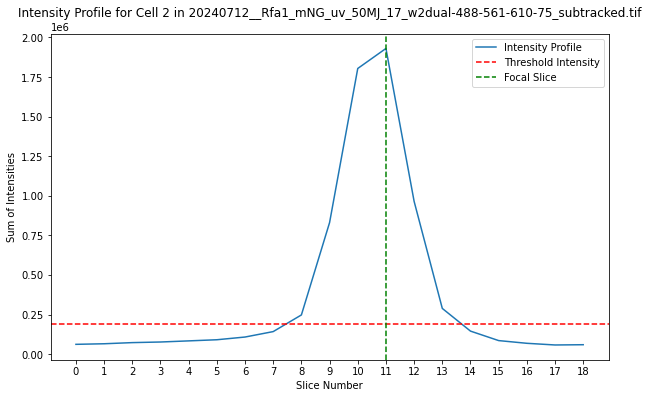

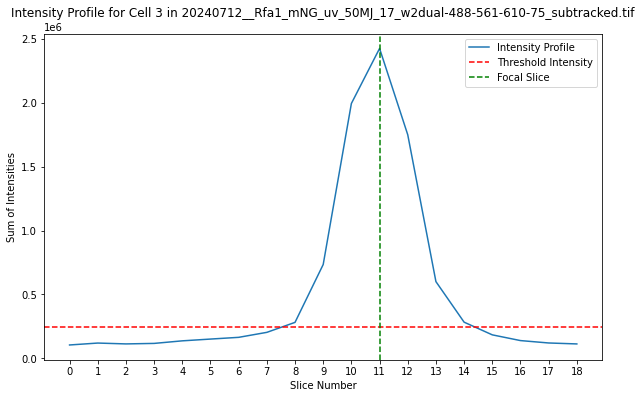

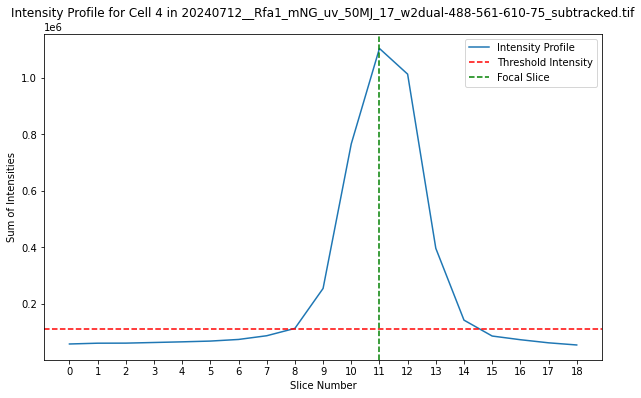

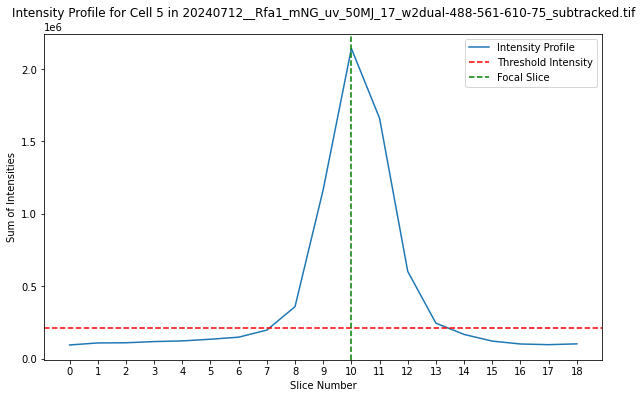

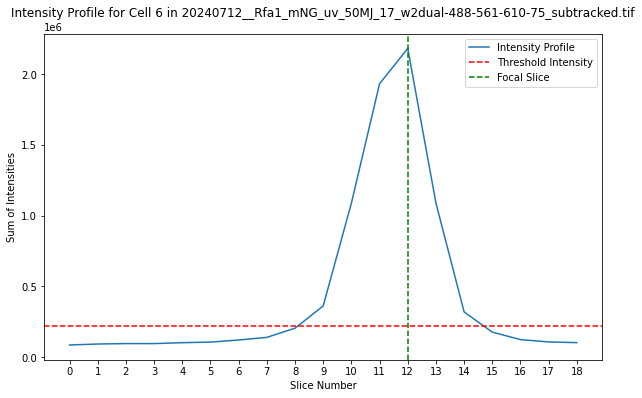

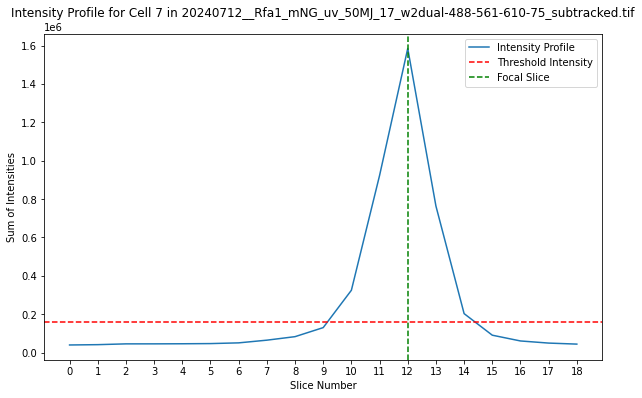

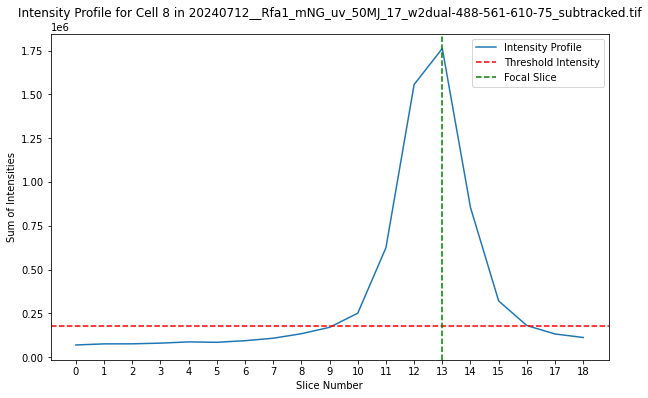

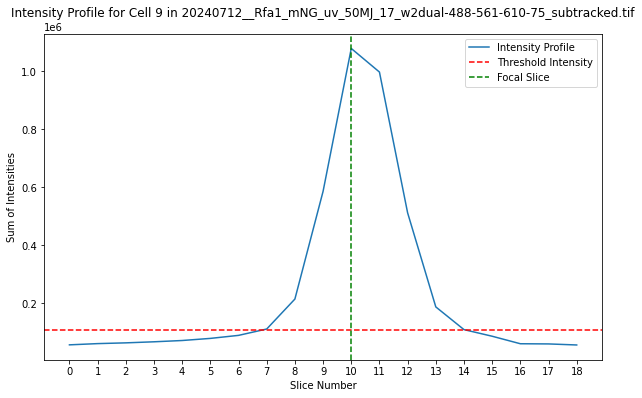

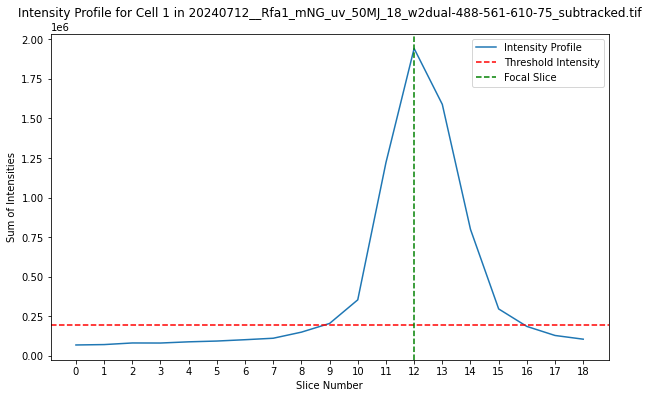

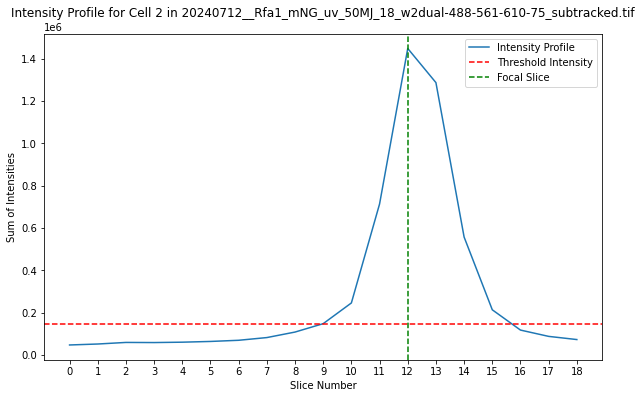

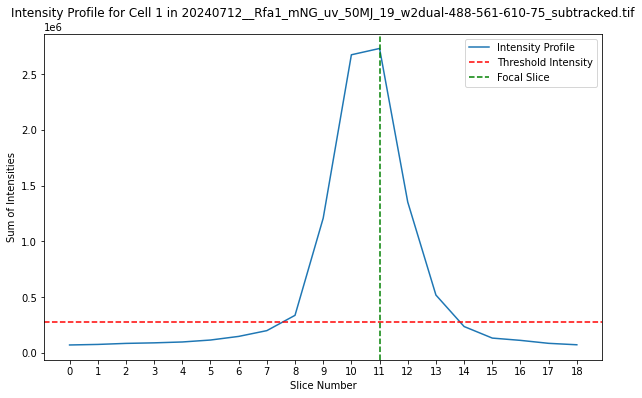

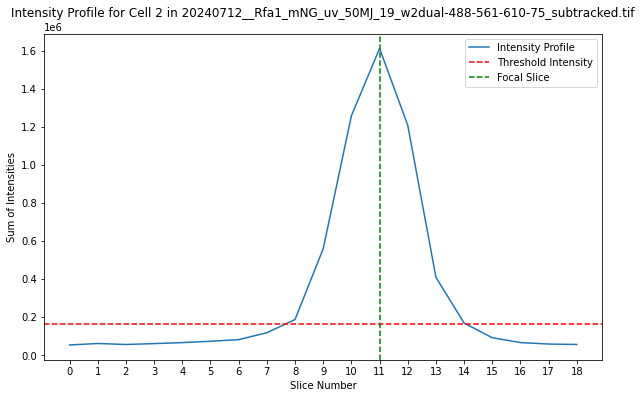

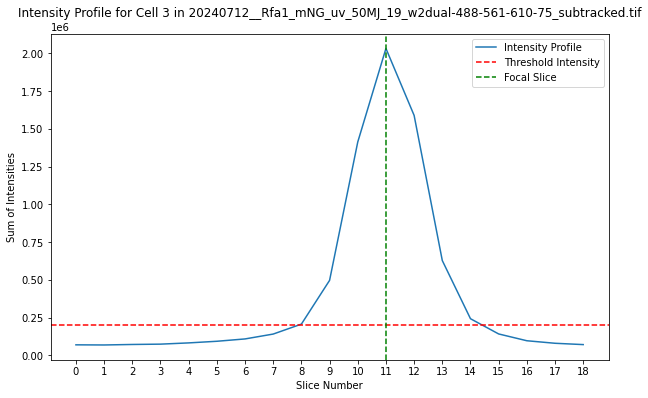

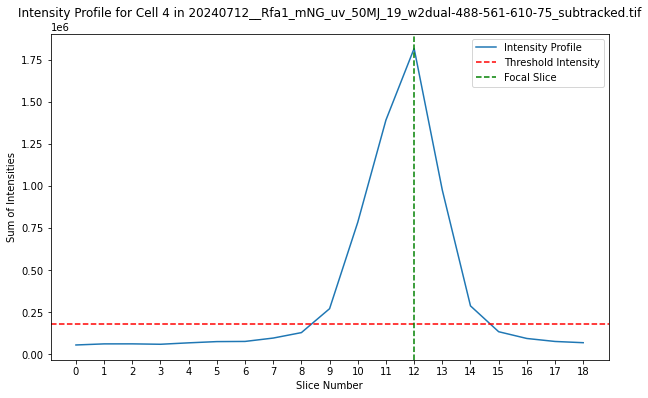

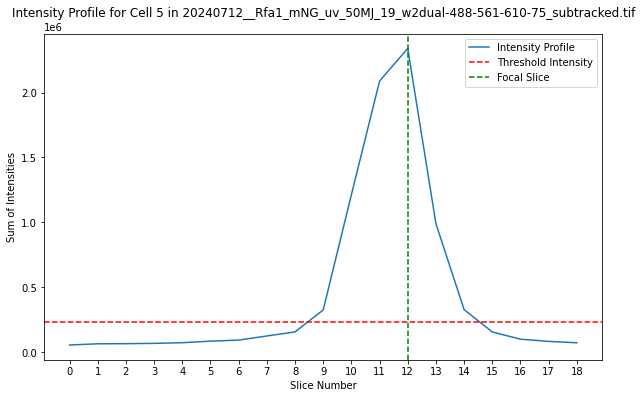

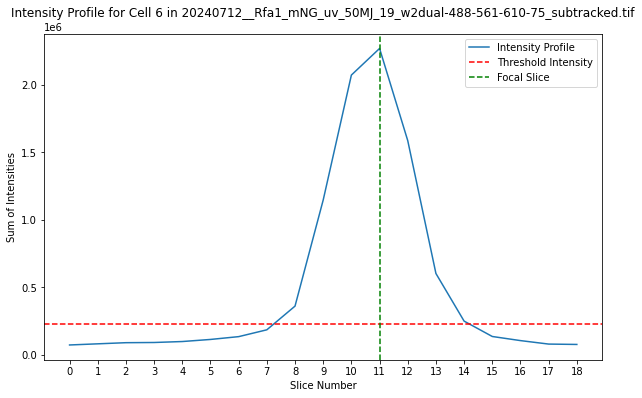

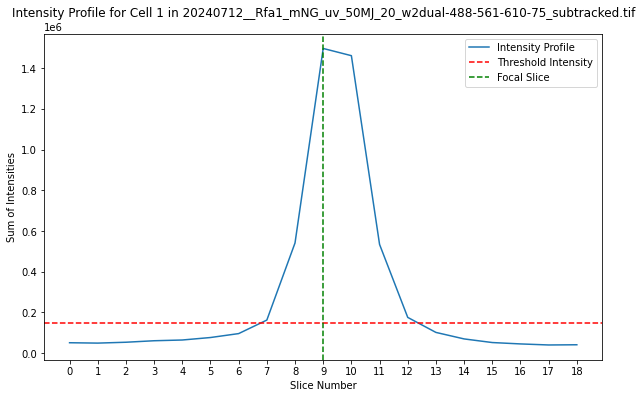

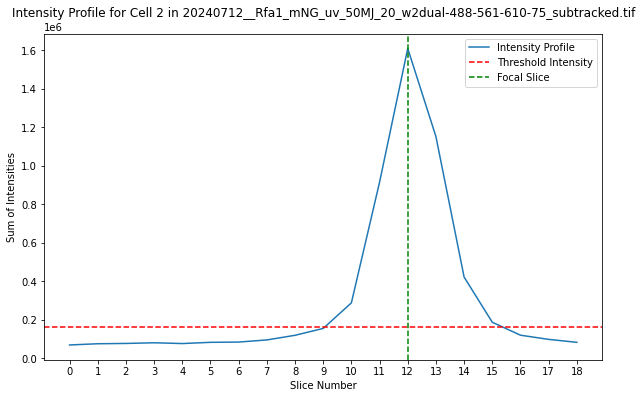

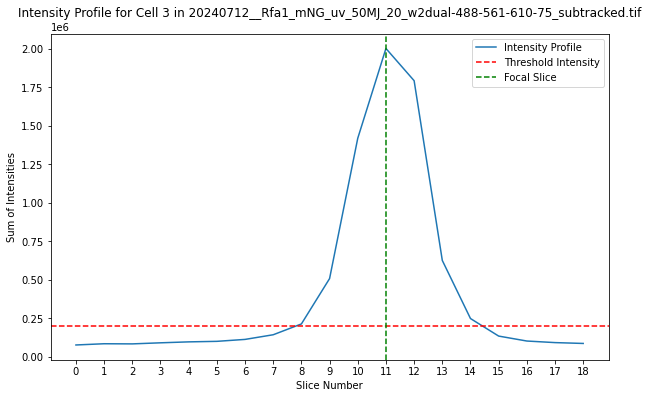

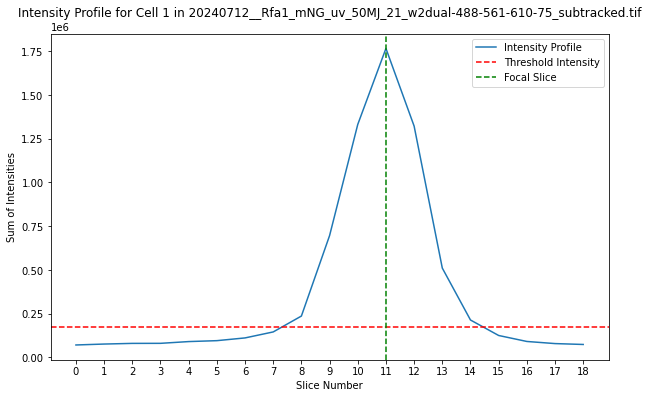

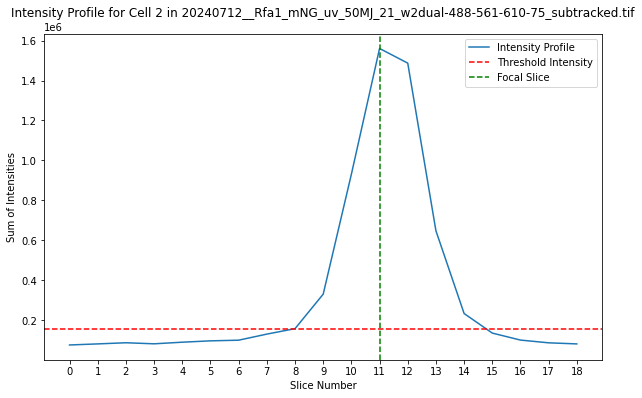

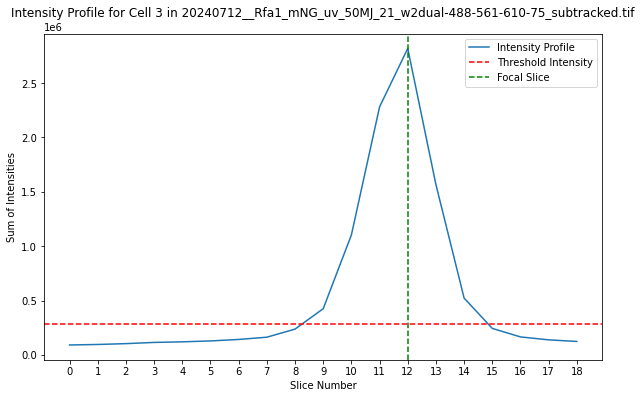

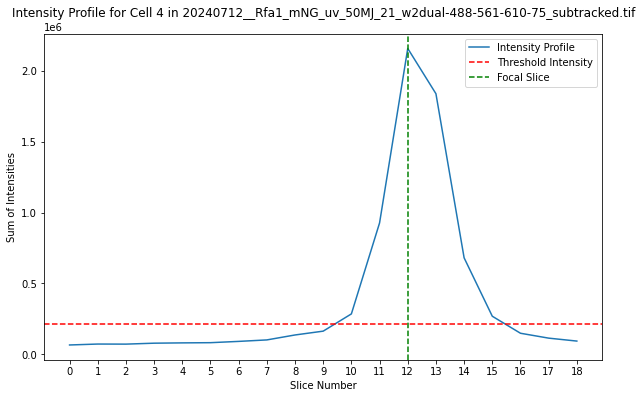

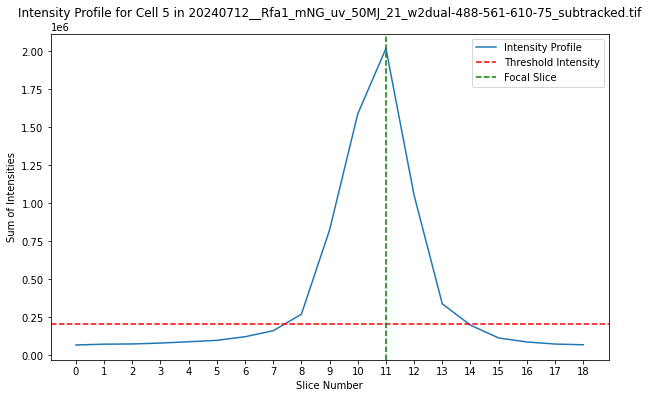

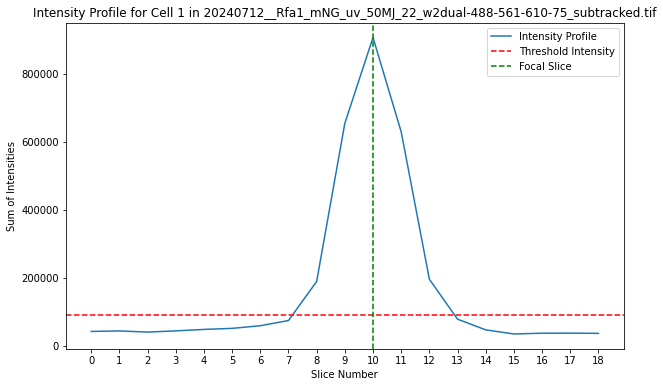

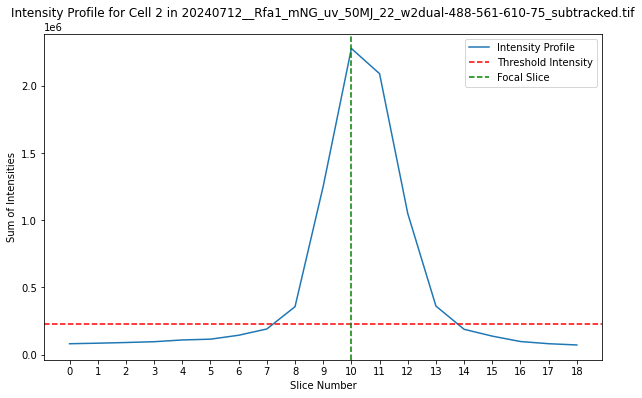

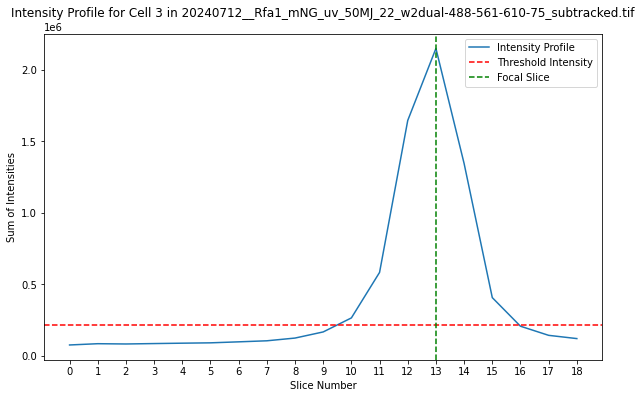

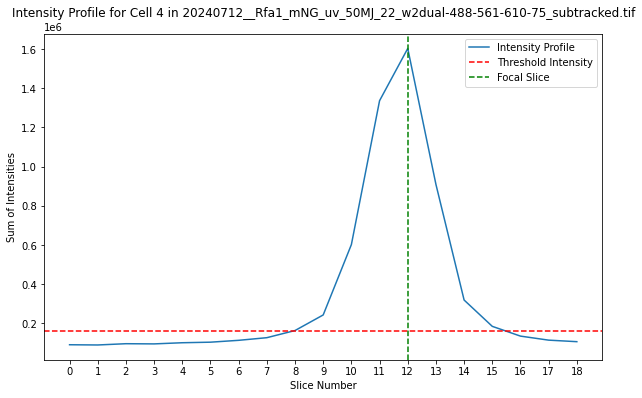

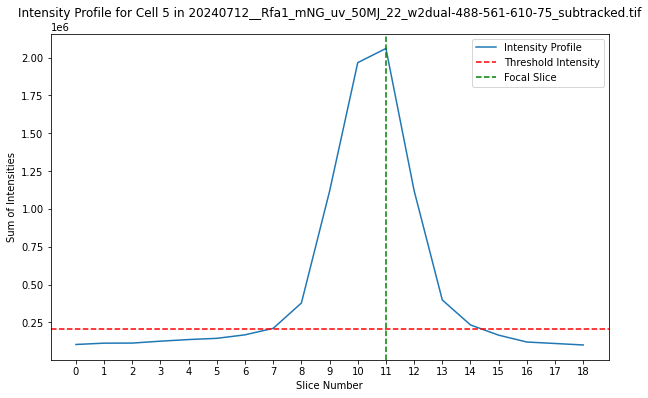

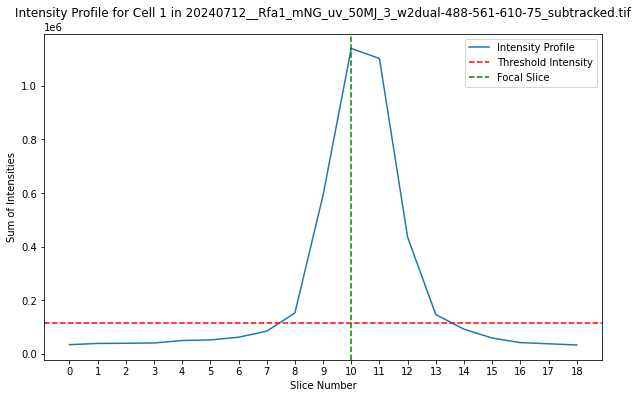

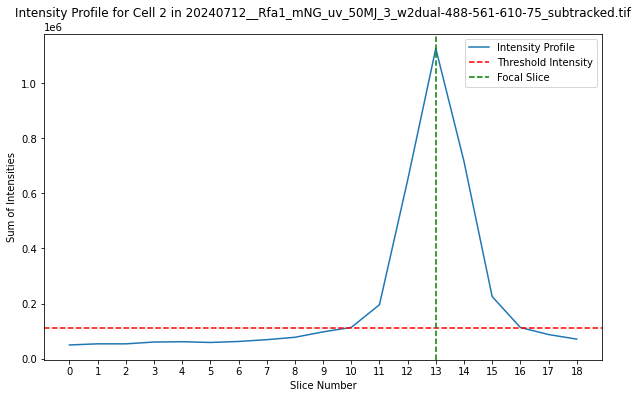

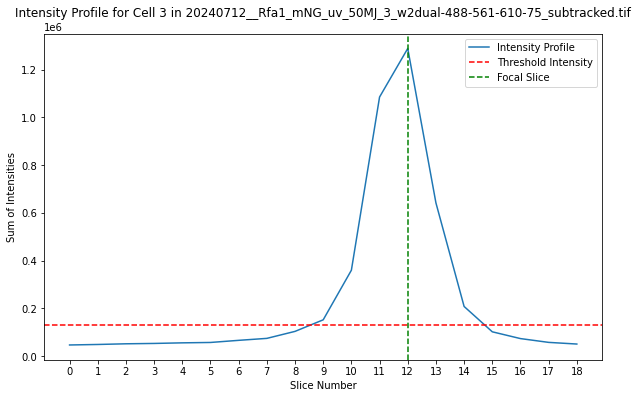

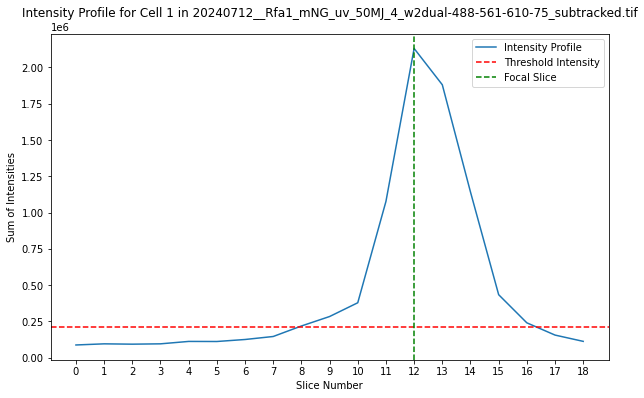

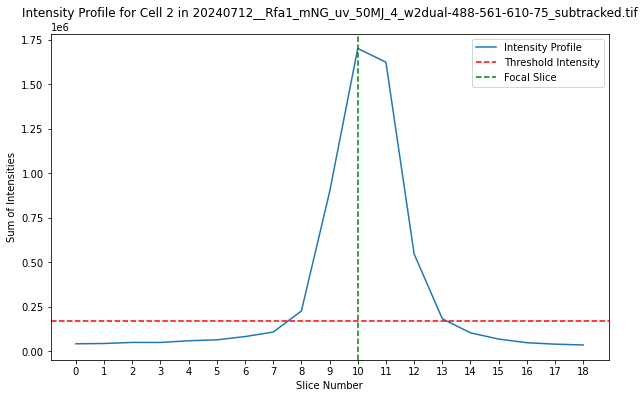

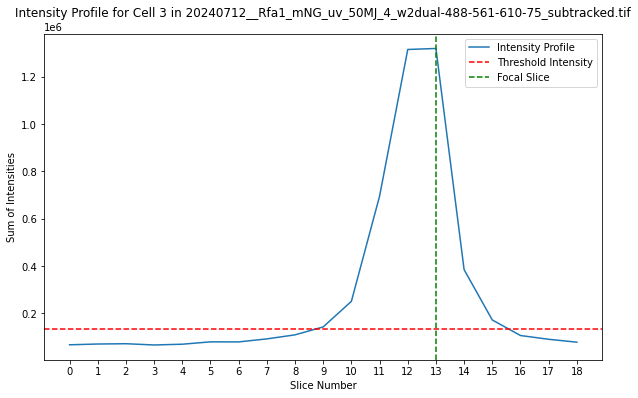

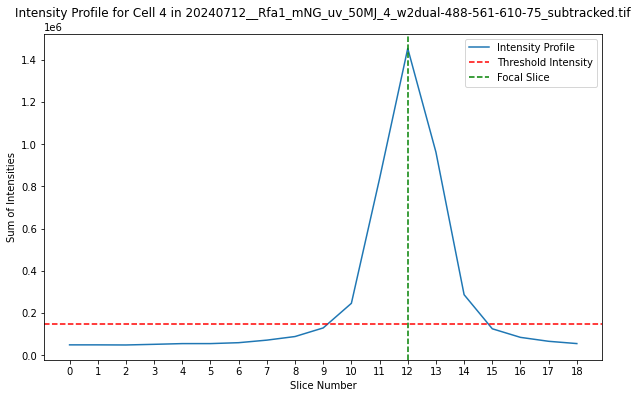

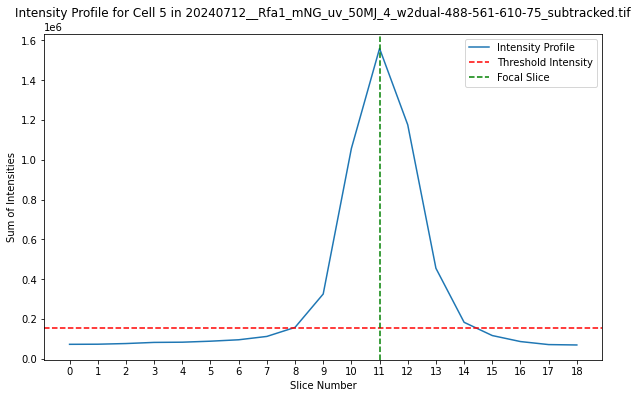

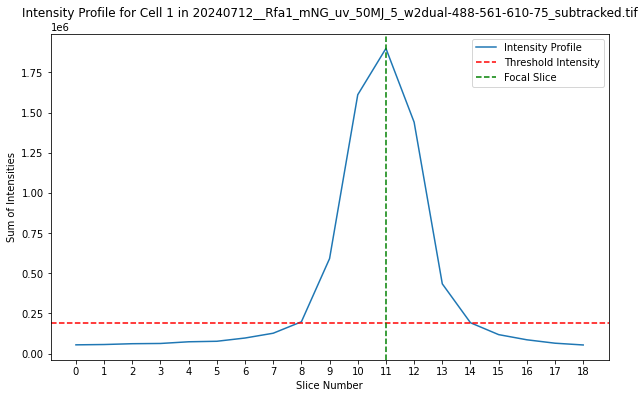

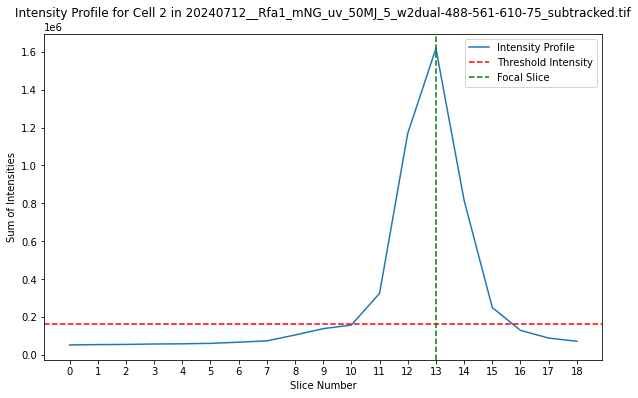

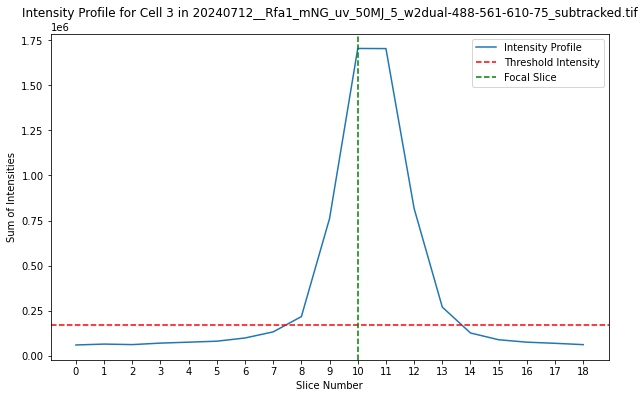

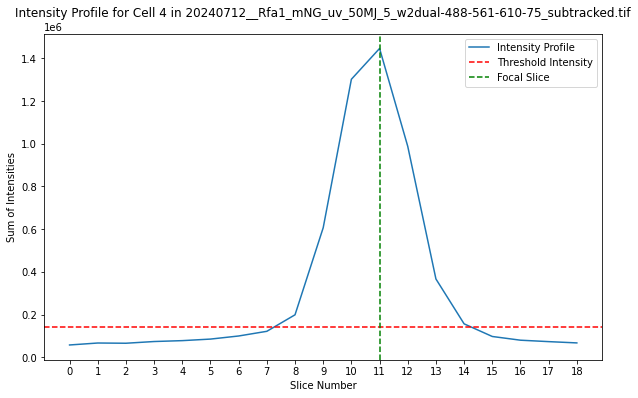

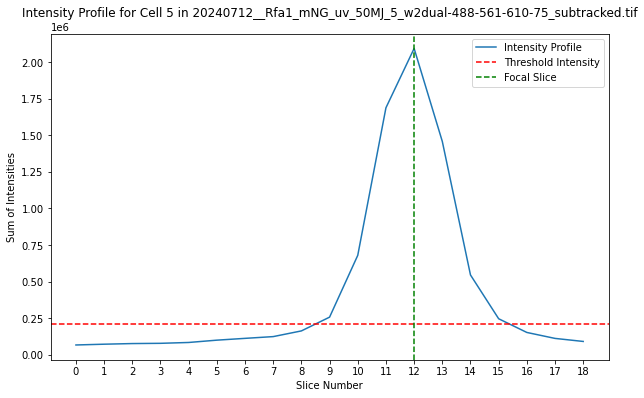

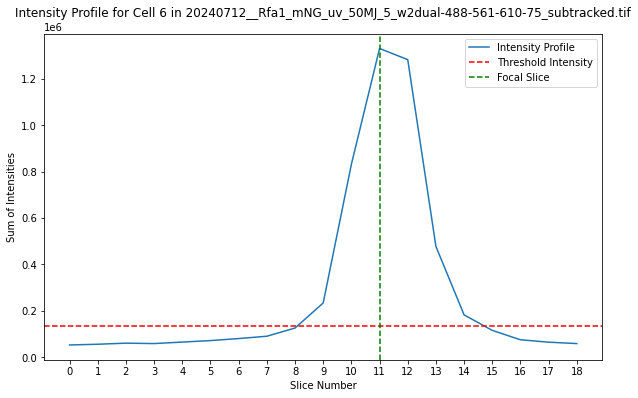

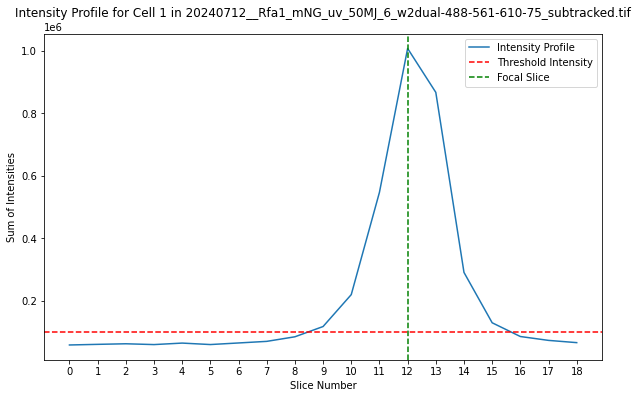

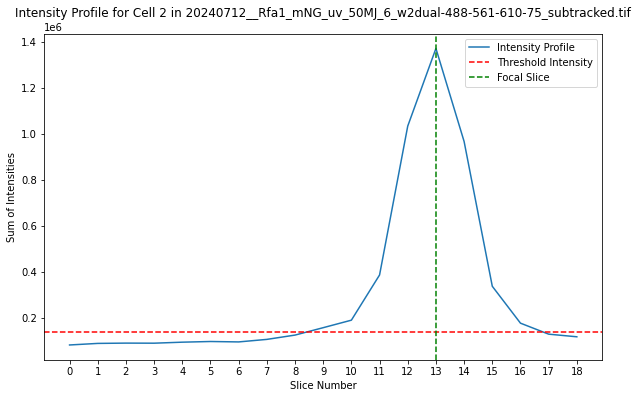

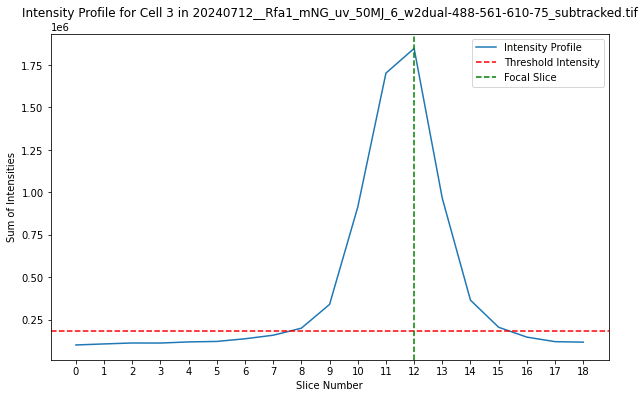

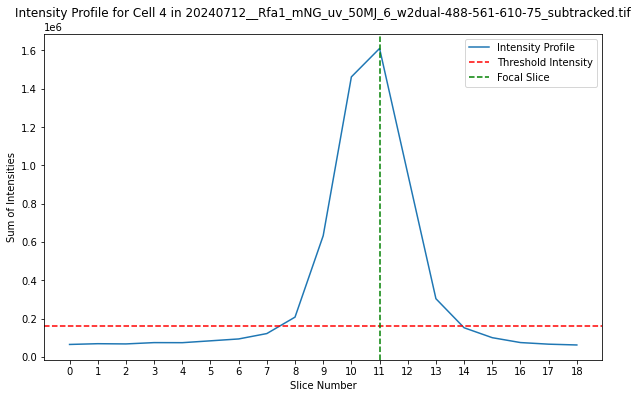

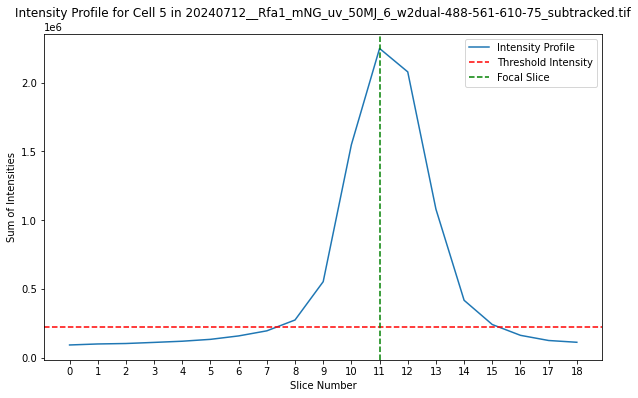

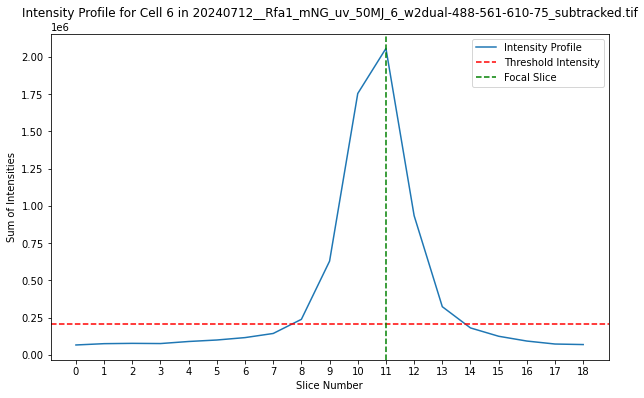

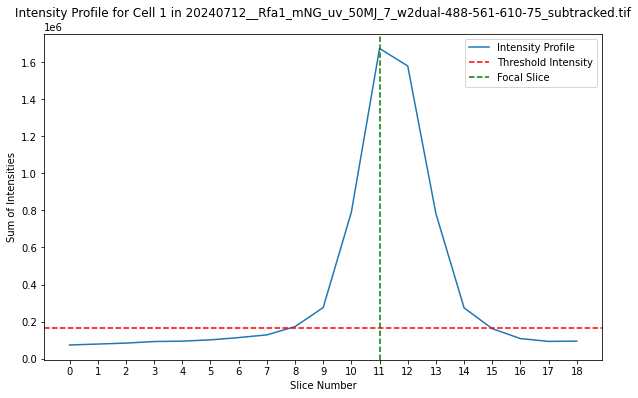

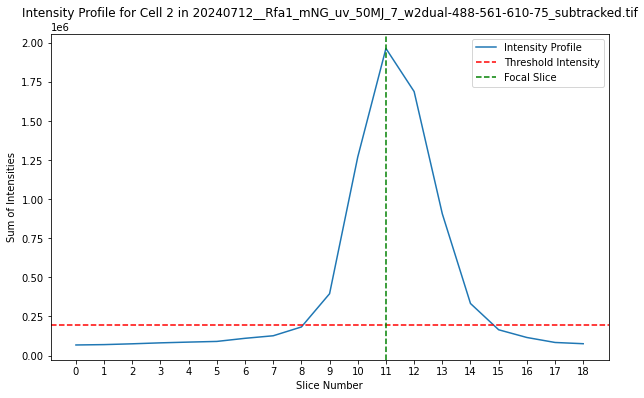

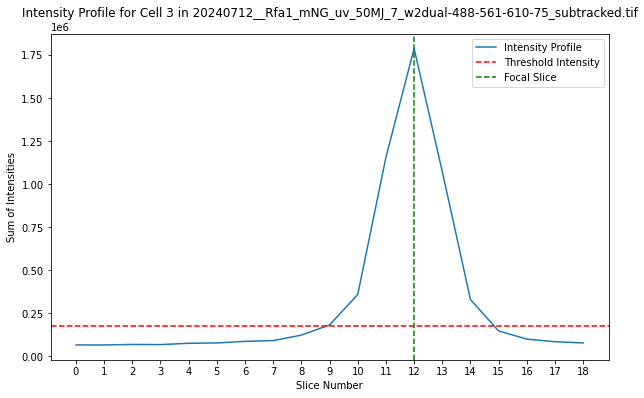

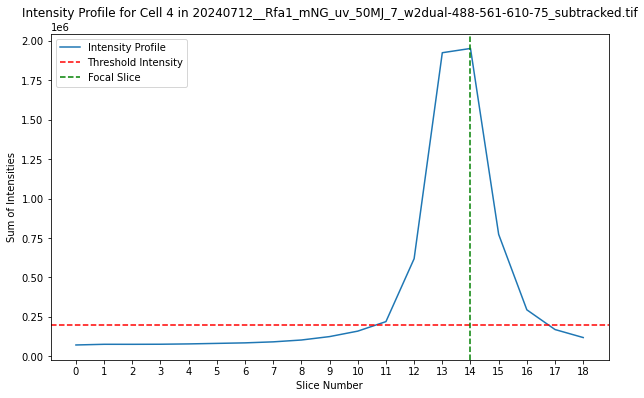

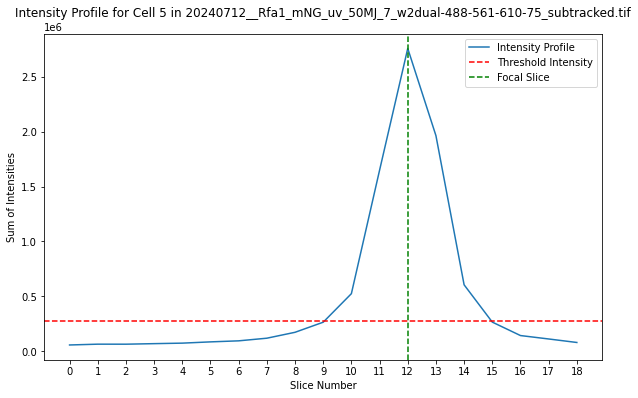

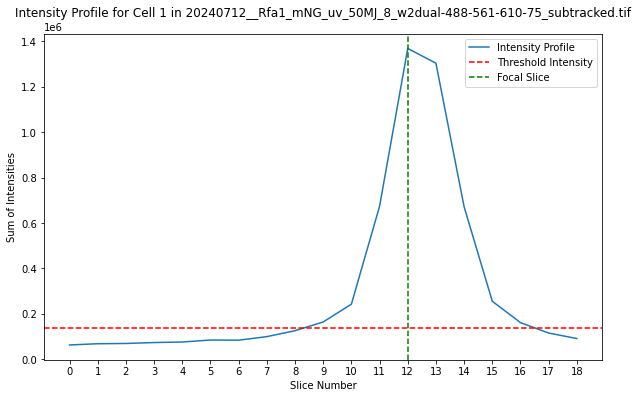

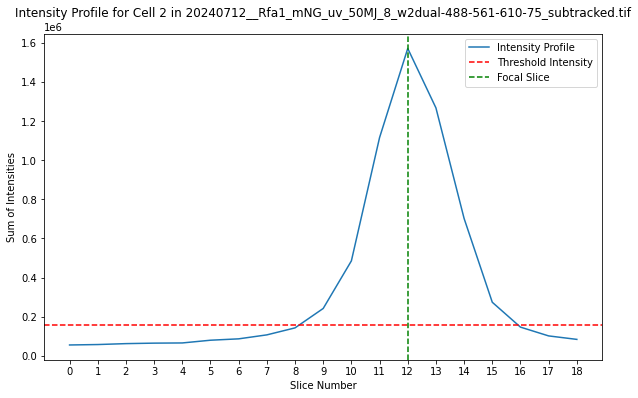

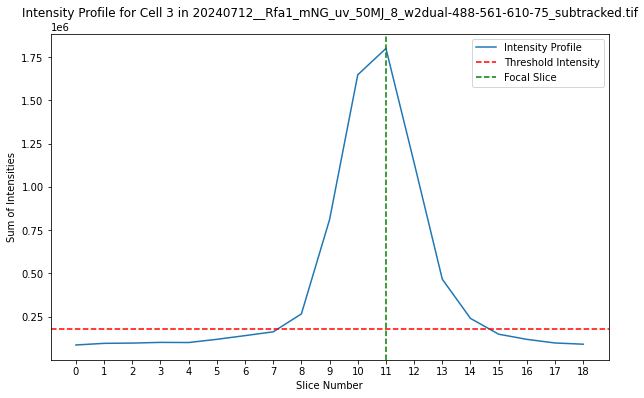

In [15]:
segmented_stacks_df = find_active_slices_by_intensity_drop(segmented_stacks_df, drop_threshold=90)

### Calculating the cell intensity and autoflourescent correction

In [16]:
segmented_stacks_df = cell_intensity(segmented_stacks_df, rg = 9.390, ra = 1.137)
# normalized intensity

In [17]:
len(segmented_stacks_df)

98

In [24]:
segmented_stacks_df.head()

,File Name,Cell ID,Segmented Stack,Segmented RFP,Focal Slice Index,Focal Intensity,Threshold Intensity,Active Slices,total intensity,total background,total intensity normal,Copy number
0,20240712__Rfa1_mNG_uv_50MJ_10_w2dual-488-561-6...,1,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",9,1703857,170385.7,"[7, 8, 9, 10, 11, 12]",4854475.0,497988.0,4.879048e+06,6863.199288
1,20240712__Rfa1_mNG_uv_50MJ_10_w2dual-488-561-6...,2,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",11,1252700,125270.0,"[9, 10, 11, 12, 13, 14]",3795200.0,439260.0,3.749812e+06,5274.739220
2,20240712__Rfa1_mNG_uv_50MJ_10_w2dual-488-561-6...,3,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",11,2018346,201834.6,"[9, 10, 11, 12, 13, 14]",6221534.0,611990.0,6.286967e+06,8843.672334
3,20240712__Rfa1_mNG_uv_50MJ_10_w2dual-488-561-6...,4,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",12,1810694,181069.4,"[9, 10, 11, 12, 13, 14]",5486640.0,498508.0,5.597633e+06,7874.008778
4,20240712__Rfa1_mNG_uv_50MJ_10_w2dual-488-561-6...,5,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",11,1534279,153427.9,"[9, 10, 11, 12, 13, 14]",4309376.0,424616.0,4.353769e+06,6124.306164


### Intensity distribution for all the cells

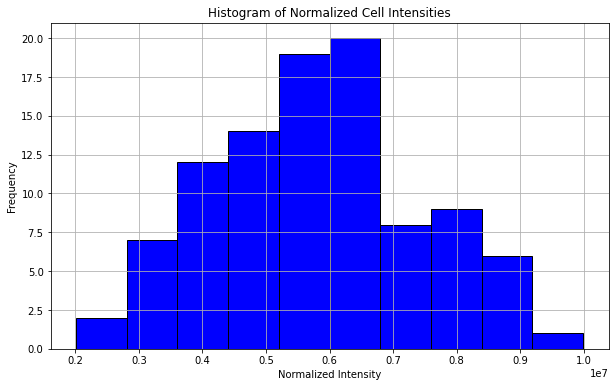

In [18]:
# the last parameter is the number of bins for the histogram
plot_cell_intensity_histogram(segmented_stacks_df, 'total intensity normal',10)

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


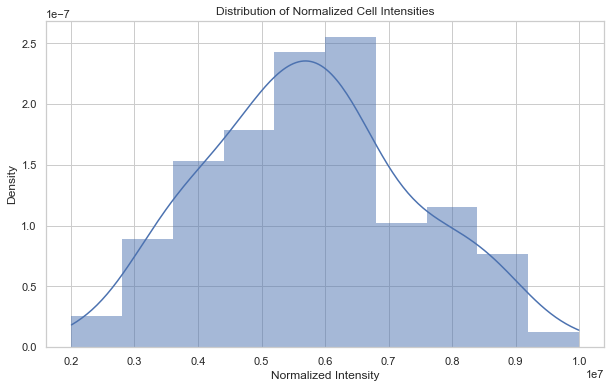

In [26]:
plot_intensity_distribution(segmented_stacks_df, 'total intensity normal',10)

### Saving the dataframe as a pickle file in the desired location
## Attention: pick the correct location and name to save the current results

In [28]:
# Saving the DataFrame to a specific location
segmented_stacks_df.to_pickle('/Volumes/Masoumeh/Masoumeh/Masoumeh_data/1-Rfa1/confocal/Rfa1_UV_segmented_stacks_df.pkl')



### You can use this box to load your files
make sure you put a good name for the variable that you put your loaded data in

In [12]:
# make sure you give the correct directory and the corresponding name
#df_loaded = pd.read_pickle('/Volumes/Masoumeh/Masoumeh/Masoumeh_data/PCNA/confocal/20240320/subtracked/split/masks/PCNA_segmented_stacks_df.pkl')
with open('/Volumes/Masoumeh/Masoumeh/Masoumeh_data/1-Rfa1/confocal/20240405_Rfa1_mNG_200mM_HU/subtracked/split/masks/RFA1_HU_segmented_stacks_df.pkl', 'rb') as file:
    df_HU= pd.read_pickle(file)


In [13]:
with open('/Volumes/Masoumeh/Masoumeh/Masoumeh_data/1-Rfa1/confocal/20240322_Rfa1_normal/subtracked/split/masks/RFA1_segmented_stacks_df.pkl', 'rb') as file:
    df_normal= pd.read_pickle(file)

In [14]:
with open('/Volumes/Masoumeh/Masoumeh/Masoumeh_data/1-Rfa1/confocal/20240403_Rfa1_mNG_CPT_40uM/subtracked/split/masks/RFA1_CPT_segmented_stacks_df.pkl', 'rb') as file:
    df_CPT= pd.read_pickle(file)

In [19]:
with open('/Volumes/Masoumeh/Masoumeh/Masoumeh_data/1-Rfa1/confocal/20240712_RFA1_UV/Rfa1_UV_segmented_stacks_df.pkl', 'rb') as file:
    df_UV= pd.read_pickle(file)

In [17]:
df_normal['Copy number'] = df_normal['total intensity normal'] / 710.90
df_CPT['Copy number'] = df_CPT['total intensity normal'] / 710.90
df_HU['Copy number'] = df_HU['total intensity normal'] / 710.90

In [18]:
df_normal.head()

,File Name,Cell ID,Segmented Stack,Segmented RFP,Focal Slice Index,Focal Intensity,Threshold Intensity,Active Slices,total intensity,total background,total intensity normal,Copy number
0,20240322_Rfa1_mNG_copynumber_10_w2dual-488-561...,1,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",10,1877181,375436.2,"[8, 9, 10, 11, 12]",5693475.0,768493.0,5.483699e+06,7713.741852
1,20240322_Rfa1_mNG_copynumber_10_w2dual-488-561...,2,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",11,1453772,290754.4,"[10, 11, 12, 13]",3856661.0,567837.0,3.653408e+06,5139.130438
2,20240322_Rfa1_mNG_copynumber_10_w2dual-488-561...,3,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",11,1764755,352951.0,"[10, 11, 12, 13]",5213278.0,695111.0,5.032276e+06,7078.740079
3,20240322_Rfa1_mNG_copynumber_12_w2dual-488-561...,1,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",12,982836,196567.2,"[10, 11, 12, 13, 14]",3249769.0,365283.0,3.224938e+06,4536.415677
4,20240322_Rfa1_mNG_copynumber_12_w2dual-488-561...,2,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",10,2288985,457797.0,"[8, 9, 10, 11, 12]",6663087.0,662364.0,6.724186e+06,9458.694100


In [28]:
df_HU.head()

,File Name,Cell ID,Segmented Stack,Segmented RFP,Focal Slice Index,Focal Intensity,Threshold Intensity,Active Slices,total intensity,total background,total intensity normal,Condition
0,20240403_Rfa1_mNG_HU_200mM_30_w2dual-488-561-6...,1,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",14,943232,188646.4,"[12, 13, 14, 15, 16]",3029828.0,267396.0,3.101327e+06,200mM Hydroxyurea
1,20240403_Rfa1_mNG_HU_200mM_30_w2dual-488-561-6...,2,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",9,2142899,428579.8,"[7, 8, 9, 10, 11]",6890857.0,550685.0,7.127808e+06,200mM Hydroxyurea
2,20240403_Rfa1_mNG_HU_200mM_30_w2dual-488-561-6...,3,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",13,1870256,374051.2,"[10, 11, 12, 13, 14, 15]",7026437.0,707005.0,7.079844e+06,200mM Hydroxyurea
3,20240403_Rfa1_mNG_HU_200mM_30_w2dual-488-561-6...,4,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",11,1787466,357493.2,"[8, 9, 10, 11, 12, 13]",6278742.0,685369.0,6.257130e+06,200mM Hydroxyurea
4,20240403_Rfa1_mNG_HU_200mM_30_w2dual-488-561-6...,5,"[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...",10,1900192,380038.4,"[8, 9, 10, 11, 12]",6800907.0,592813.0,6.970967e+06,200mM Hydroxyurea


## Plotting the distribution of intensities for different condition (overlaid)

In [20]:
def plot_overlayed_intensity_distribution(dataframe, intensity_column, condition_column, bin_number):
    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 8))

    # Create the overlayed histogram with a density plot
    sns.histplot(data=dataframe, x=intensity_column, hue=condition_column, kde=True,bins = bin_number, 
                 element='step', stat="density", common_norm=False, palette='viridis', alpha=0.5)

    # Adding labels and title to the plot
    plt.title('Overlayed Distribution of Cell Intensities under Different Conditions')
    plt.xlabel('Copy number')
    plt.ylabel('Density')

    # Show the plot
    #plt.legend(title=condition_column)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[1:], labels=labels[1:], title=condition_column) # skip the first handle/label
    plt.show()


/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

NameError: name 'ax' is not defined

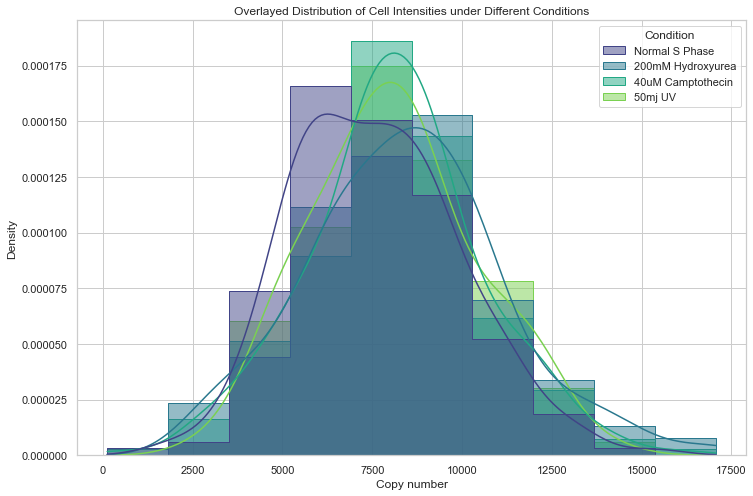

In [21]:
# Assume df_normal, df_HU, df_CPT are your three DataFrames
# and each has a 'total intensity normal' column.

# Add a 'Condition' column to each DataFrame, you can add more condtion or protein as desired
df_normal['Condition'] = 'Normal S Phase'
df_HU['Condition'] = '200mM Hydroxyurea'
df_CPT['Condition'] = '40uM Camptothecin'
df_UV['Condition'] = '50mj UV'

# Concatenate the separate DataFrames into one
combined_df = pd.concat([df_normal,df_HU,df_CPT,df_UV], ignore_index=True) # make sure you inclued all of the dataframes from different condition
# plot the normalized intensity distribution
plot_overlayed_intensity_distribution(combined_df, 'Copy number', 'Condition', 10) # last parameter : bin number

## Plotting the histogram of normalized intensity for different conditions (overlaid)

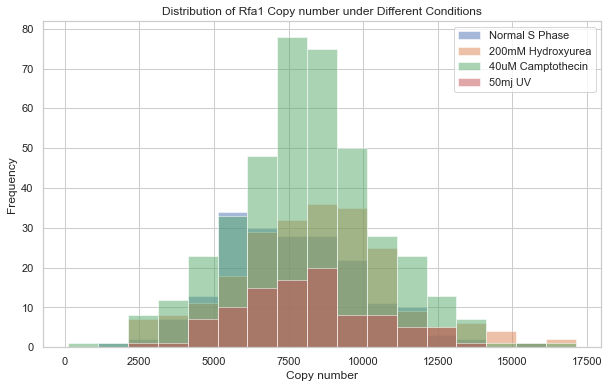

In [24]:
# Assuming df_normal, df_HU, df_CPT have been defined and have the column 'total intensity normal'

bin_width = 1000

# Calculate global min and max to ensure same bin edges for all conditions
global_min = min(df_normal['Copy number'].min(), df_HU['Copy number'].min(),df_CPT['Copy number'].min(),df_UV['Copy number'].min())
global_max = max(df_normal['Copy number'].max(), df_HU['Copy number'].max(),df_CPT['Copy number'].max(),df_UV['Copy number'].max())

# Calculate bin edges
bins = np.arange(global_min, global_max + bin_width, bin_width)

plt.figure(figsize=(10, 6))

# Plot histograms for each condition
plt.hist(df_normal['Copy number'], bins=bins, alpha=0.5, label='Normal S Phase')
plt.hist(df_HU['Copy number'], bins=bins, alpha=0.5, label='200mM Hydroxyurea')
plt.hist(df_CPT['Copy number'], bins=bins, alpha=0.5, label='40uM Camptothecin')
plt.hist(df_UV['Copy number'], bins=bins, alpha=0.5, label='50mj UV')

# Add lables and title
plt.title('Distribution of Rfa1 Copy number under Different Conditions') # you can change the title and lables as desired
plt.xlabel('Copy number')
plt.ylabel('Frequency')

# Show legend
plt.legend()
plt.show()


# Plot the box plot of copy number of proteins in different conditions

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

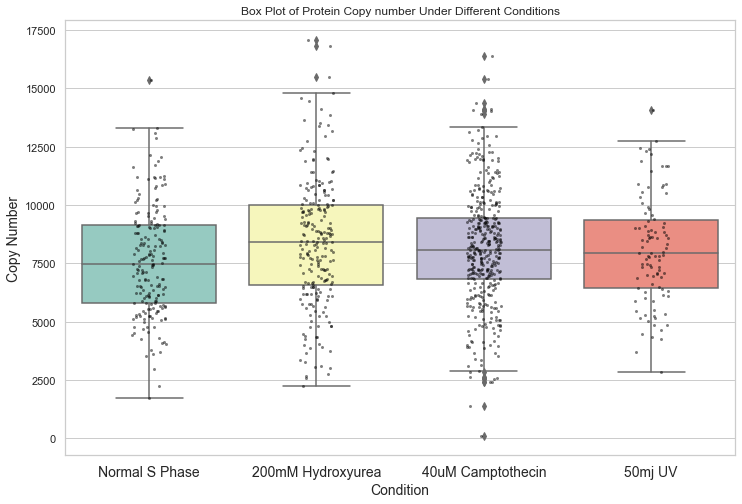

In [25]:
# Add a 'Condition' column to each DataFrame, add conditions as desired - UV or other proteins
df_normal['Condition'] = 'Normal S Phase'
df_HU['Condition'] = '200mM Hydroxyurea'
df_CPT['Condition'] = '40uM Camptothecin'
df_UV['Condition'] = '50mj UV'

combined_df = pd.concat([df_normal,df_HU, df_CPT,df_UV], ignore_index=True) # add conditions as desired

plt.figure(figsize=(12, 8))

# Create a box plot
sns.boxplot(x='Condition', y='Copy number', data=combined_df, palette="Set3")

# Overlay individual points with stripplot
sns.stripplot(x='Condition', y='Copy number', data=combined_df, jitter=True, color='black', size=3, alpha=0.5)

plt.title('Box Plot of Protein Copy number Under Different Conditions')
plt.xlabel('Condition', fontsize = 14)
plt.ylabel('Copy Number', fontsize = 14)
plt.xticks(fontsize=14)
plt.show()


## Average copy number of protein in different condition, and the % of increase

In [27]:

# Calculate the mean and standard deviation for each condition
mean_normal = df_normal['Copy number'].mean()
std_normal = df_normal['Copy number'].std()
n_normal = df_normal['Copy number'].count()

mean_HU = df_HU['Copy number'].mean()
std_HU = df_HU['Copy number'].std()
n_HU = df_HU['Copy number'].count()

mean_CPT = df_CPT['Copy number'].mean()
std_CPT = df_CPT['Copy number'].std()
n_CPT = df_CPT['Copy number'].count()

mean_UV = df_UV['Copy number'].mean()
std_UV = df_UV['Copy number'].std()
n_UV = df_UV['Copy number'].count()



print(f"Mean Copy Number (Normal S Phase): {mean_normal:.2f} ± {std_normal:.2f} (n={n_normal})")
print(f"Mean Copy Number (200mM Hydroxyurea): {mean_HU:.2f} ± {std_HU:.2f} (n={n_HU})")
print(f"Mean Copy Number (40uM Camptothecin): {mean_CPT:.2f} ± {std_CPT:.2f} (n={n_CPT})")
print(f"Mean Copy Number (50mj UV): {mean_UV:.2f} ± {std_UV:.2f} (n={n_UV})")

# Calculate the percentage increase
increase_HU = ((mean_HU - mean_normal) / mean_normal) * 100
increase_CPT = ((mean_CPT - mean_normal) / mean_normal) * 100
increase_UV = ((mean_UV - mean_normal) / mean_normal) * 100

print(f"Mean Copy Number (Normal S Phase): {mean_normal:.2f}")
print(f"Mean Copy Number (200mM Hydroxyurea): {mean_HU:.2f} ({increase_HU:.2f}% increase)")
print(f"Mean Copy Number (40uM Camptothecin): {mean_CPT:.2f} ({increase_CPT:.2f}% increase)")
print(f"Mean Copy Number (50mj UV): {mean_UV:.2f} ({increase_UV:.2f}% increase)")


Mean Copy Number (Normal S Phase): 7603.02 ± 2326.12 (n=192)
Mean Copy Number (200mM Hydroxyurea): 8388.62 ± 2723.63 (n=228)
Mean Copy Number (40uM Camptothecin): 8131.12 ± 2445.02 (n=403)
Mean Copy Number (50mj UV): 8108.29 ± 2300.57 (n=98)
Mean Copy Number (Normal S Phase): 7603.02
Mean Copy Number (200mM Hydroxyurea): 8388.62 (10.33% increase)
Mean Copy Number (40uM Camptothecin): 8131.12 (6.95% increase)
Mean Copy Number (50mj UV): 8108.29 (6.65% increase)


# plotting the distribution of copy number

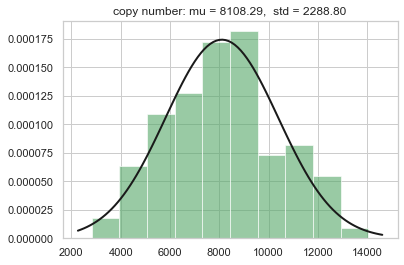

Fitted Average: 8108.294395576853


In [28]:
# Assuming df_normal['Copy number'] is your data
copy_numbers = df_UV['Copy number']


# Visualize the data
plt.hist(copy_numbers, bins=10, density=True, alpha=0.6, color='g')

# Fit to a normal distribution
mu, std = stats.norm.fit(copy_numbers)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

# Plot the fitted distribution
plt.plot(x, p, 'k', linewidth=2)
title = "copy number: mu = %.2f,  std = %.2f" % (mu, std)
plt.title(title)

plt.show()

# Average from fitted distribution
fitted_average = mu
print("Fitted Average:", fitted_average)


In [29]:

# Add a 'Condition' column to each DataFrame
df_normal['Condition'] = 'Normal S Phase'
df_HU['Condition'] = '200mM Hydroxyurea'
df_CPT['Condition'] = '40uM Camptothecin'
df_UV['Condition'] = '50mj UV'

df_normal['Bound fraction'] = 0.46
df_HU['Bound fraction'] = 0.35
df_CPT['Bound fraction'] = 0.24
df_UV['Bound fraction'] = 0.57
# Assuming 'Bound fraction' is a column in each DataFrame
# Calculate chromatin-bound copy number for each cell
df_normal['Chromatin-bound Copy Number'] = df_normal['Copy number'] * df_normal['Bound fraction']
df_HU['Chromatin-bound Copy Number'] = df_HU['Copy number'] * df_HU['Bound fraction']
df_CPT['Chromatin-bound Copy Number'] = df_CPT['Copy number'] * df_CPT['Bound fraction']
df_UV['Chromatin-bound Copy Number'] = df_UV['Copy number'] * df_UV['Bound fraction']

# Calculate the mean and standard deviation of chromatin-bound copy number for each condition
mean_cb_normal = df_normal['Chromatin-bound Copy Number'].mean()
std_cb_normal = df_normal['Chromatin-bound Copy Number'].std()
n_cb_normal = df_normal['Chromatin-bound Copy Number'].count()

mean_cb_HU = df_HU['Chromatin-bound Copy Number'].mean()
std_cb_HU = df_HU['Chromatin-bound Copy Number'].std()
n_cb_HU = df_HU['Chromatin-bound Copy Number'].count()

mean_cb_CPT = df_CPT['Chromatin-bound Copy Number'].mean()
std_cb_CPT = df_CPT['Chromatin-bound Copy Number'].std()
n_cb_CPT = df_CPT['Chromatin-bound Copy Number'].count()

mean_cb_UV = df_UV['Chromatin-bound Copy Number'].mean()
std_cb_UV = df_UV['Chromatin-bound Copy Number'].std()
n_cb_UV = df_UV['Chromatin-bound Copy Number'].count()

print(f"Chromatin-bound Copy Number (Normal S Phase): {mean_cb_normal:.2f} ± {std_cb_normal:.2f} (n={n_cb_normal})")
print(f"Chromatin-bound Copy Number (200mM Hydroxyurea): {mean_cb_HU:.2f} ± {std_cb_HU:.2f} (n={n_cb_HU})")
print(f"Chromatin-bound Copy Number (40uM Camptothecin): {mean_cb_CPT:.2f} ± {std_cb_CPT:.2f} (n={n_cb_CPT})")
print(f"Chromatin-bound Copy Number (50mj UV): {mean_cb_UV:.2f} ± {std_cb_UV:.2f} (n={n_cb_UV})")


Chromatin-bound Copy Number (Normal S Phase): 3497.39 ± 1070.02 (n=192)
Chromatin-bound Copy Number (200mM Hydroxyurea): 2936.02 ± 953.27 (n=228)
Chromatin-bound Copy Number (40uM Camptothecin): 1951.47 ± 586.80 (n=403)
Chromatin-bound Copy Number (50mj UV): 4621.73 ± 1311.33 (n=98)


In [33]:
import scipy.stats as stats

# Example data for two conditions
normal = df_normal['Copy number']  # Replace with your data
HU = df_HU['Copy number'] # Replace with your data
CPT = df_CPT['Copy number']
UV = df_UV['Copy number']
# Independent t-test
t_stat_HU, p_val_HU = stats.ttest_ind(normal, HU)
t_stat_CPT, p_val_CPT = stats.ttest_ind(normal, CPT)
t_stat_UV, p_val_UV = stats.ttest_ind(normal, UV)

print(f"200mM HU: t-statistic: {t_stat_HU}, p-value: {p_val_HU}")
print(f"40uM CPT: t-statistic: {t_stat_CPT}, p-value: {p_val_CPT}")
print(f"50mj UV: t-statistic: {t_stat_UV}, p-value: {p_val_UV}")


200mM HU: t-statistic: -3.1455871860237767, p-value: 0.001775991996543814
40uM CPT: t-statistic: -2.5015632544902857, p-value: 0.012633020776510838
50mj UV: t-statistic: -1.7561416035591713, p-value: 0.08012712599844803


In [34]:
shapiro_test1 = stats.shapiro(normal)
print(f"Normal S Phase: W-statistic = {shapiro_test1.statistic}, p-value = {shapiro_test1.pvalue}")

# Shapiro-Wilk test for 200mM Hydroxyurea condition
shapiro_test2 = stats.shapiro(HU)
print(f"200mM Hydroxyurea: W-statistic = {shapiro_test2.statistic}, p-value = {shapiro_test2.pvalue}")

Normal S Phase: W-statistic = 0.9894216656684875, p-value = 0.16700637340545654
200mM Hydroxyurea: W-statistic = 0.9898907542228699, p-value = 0.11186668276786804


In [35]:
# Perform Levene's test
levene_stat, levene_p = stats.levene(normal, HU)

print(f"Levene’s test: W-statistic = {levene_stat}, p-value = {levene_p}")


Levene’s test: W-statistic = 2.586112870202203, p-value = 0.10855962420429234


In [1]:
'a' + 'b'

'ab'